Cropped array shape: (365, 611)
Unique LCZ values for London:
LCZ 0: 586 pixels
LCZ 2: 2135 pixels
LCZ 3: 1294 pixels
LCZ 4: 25 pixels
LCZ 5: 13411 pixels
LCZ 6: 106288 pixels
LCZ 8: 9484 pixels
LCZ 9: 994 pixels
LCZ 11: 11860 pixels
LCZ 12: 45229 pixels
LCZ 14: 26343 pixels
LCZ 15: 394 pixels
LCZ 16: 60 pixels
LCZ 17: 4912 pixels
Missing/NoData pixels: 586


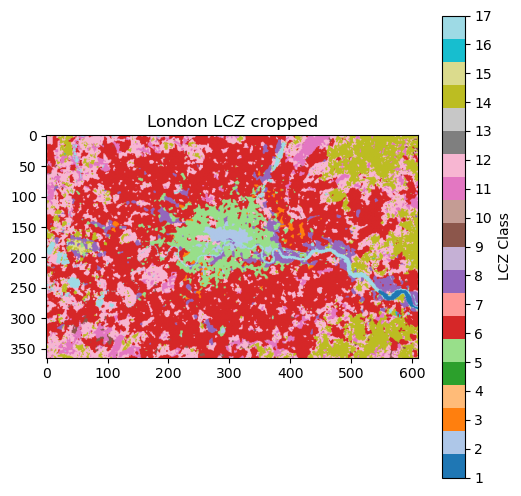

In [13]:
import rasterio
from rasterio.windows import from_bounds
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
import os

# -----------------------------
# City bounding box in lat/lon
# Format: [lat_max, lon_min, lat_min, lon_max]
# -----------------------------
city_bbox = {
    "London": [51.7, -0.5, 51.3, 0.3]
}
city_name = "London"

# -----------------------------
# File path (from Notebooks folder)
# -----------------------------
raw_lcz_path = "../Data/Raw/EU_LCZ_map.tif"

# Check file exists
if not os.path.exists(raw_lcz_path):
    raise FileNotFoundError(f"File not found: {raw_lcz_path}")

# -----------------------------
# Open raster and get CRS
# -----------------------------
with rasterio.open(raw_lcz_path) as src:
    raster_crs = src.crs  # raster coordinate system (likely EPSG:3035)
    
    # Transform lat/lon bbox to raster CRS
    lat_max, lon_min, lat_min, lon_max = city_bbox[city_name]
    transformer = Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True)
    x_min, y_min = transformer.transform(lon_min, lat_min)
    x_max, y_max = transformer.transform(lon_max, lat_max)
    
    # Create a window in raster coordinates
    window = from_bounds(
        left=x_min, bottom=y_min,
        right=x_max, top=y_max,
        transform=src.transform
    )
    
    # Read cropped data
    cropped = src.read(1, window=window)
    profile = src.profile.copy()
    nodata_val = src.nodata

# -----------------------------
# Check array size
# -----------------------------
print(f"Cropped array shape: {cropped.shape}")

# -----------------------------
# Check unique LCZ values
# -----------------------------
unique, counts = np.unique(cropped, return_counts=True)
print(f"Unique LCZ values for {city_name}:")
for val, cnt in zip(unique, counts):
    print(f"LCZ {val}: {cnt} pixels")

# -----------------------------
# Check missing/NoData pixels
# -----------------------------
if nodata_val is not None:
    missing_count = np.sum(cropped == nodata_val)
else:
    missing_count = 0
print(f"Missing/NoData pixels: {missing_count}")

# -----------------------------
# Visualize if array is big enough
# -----------------------------
if cropped.size > 1:
    plt.figure(figsize=(6,6))
    plt.imshow(cropped, cmap="tab20", vmin=1, vmax=17)
    plt.title(f"{city_name} LCZ cropped")
    cbar = plt.colorbar(ticks=range(1,18))
    cbar.set_label("LCZ Class")
    plt.show()
else:
    print("Cropped array too small to visualize. Try expanding the bounding box.")

In [14]:
import rasterio
import os

# -----------------------------
# Output path
# -----------------------------
processed_path = "../Data/Processed/London_LCZ.tif"

# Ensure the folder exists
os.makedirs(os.path.dirname(processed_path), exist_ok=True)

# -----------------------------
# Update profile for cropped array
# -----------------------------
profile.update({
    "height": cropped.shape[0],
    "width": cropped.shape[1],
    "transform": rasterio.windows.transform(window, profile["transform"])
})

# -----------------------------
# Save cropped LCZ
# -----------------------------
with rasterio.open(processed_path, "w", **profile) as dst:
    dst.write(cropped, 1)

print(f"Saved cropped LCZ for London to: {processed_path}")

Saved cropped LCZ for London to: ../Data/Processed/London_LCZ.tif


Cropped array shape: (368, 553)
Unique LCZ values for New_York:
LCZ 0: 47334 pixels
LCZ 1: 1681 pixels
LCZ 2: 18628 pixels
LCZ 3: 9987 pixels
LCZ 4: 3654 pixels
LCZ 5: 1413 pixels
LCZ 6: 86876 pixels
LCZ 8: 1984 pixels
LCZ 10: 2273 pixels
LCZ 11: 3660 pixels
LCZ 12: 8146 pixels
LCZ 14: 550 pixels
LCZ 15: 4969 pixels
LCZ 16: 56 pixels
LCZ 17: 12293 pixels
Missing/NoData pixels: 0


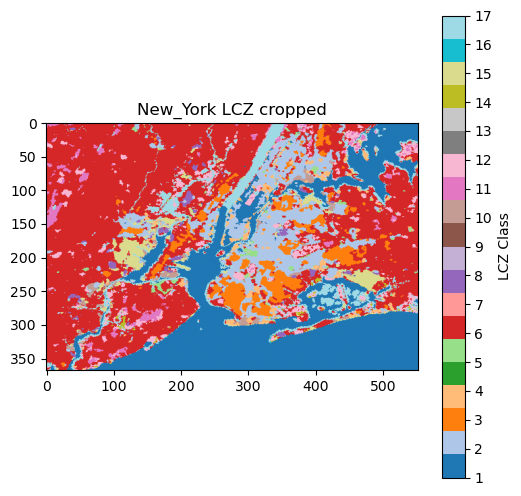

In [15]:
import rasterio
from rasterio.windows import from_bounds
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
import os

# -----------------------------
# City bounding box in lat/lon
# Format: [lat_max, lon_min, lat_min, lon_max]
# -----------------------------
city_bbox = {
    "New_York": [40.9, -74.3, 40.5, -73.7]
}
city_name = "New_York"

# -----------------------------
# File path (from Notebooks folder)
# -----------------------------
raw_lcz_path = "../Data/Raw/USA_LCZ_map.tif"

# Check file exists
if not os.path.exists(raw_lcz_path):
    raise FileNotFoundError(f"File not found: {raw_lcz_path}")

# -----------------------------
# Open raster and get CRS
# -----------------------------
with rasterio.open(raw_lcz_path) as src:
    raster_crs = src.crs  # raster coordinate system
    
    # Transform lat/lon bbox to raster CRS
    lat_max, lon_min, lat_min, lon_max = city_bbox[city_name]
    transformer = Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True)
    x_min, y_min = transformer.transform(lon_min, lat_min)
    x_max, y_max = transformer.transform(lon_max, lat_max)
    
    # Create a window in raster coordinates
    window = from_bounds(
        left=x_min, bottom=y_min,
        right=x_max, top=y_max,
        transform=src.transform
    )
    
    # Read cropped data
    cropped = src.read(1, window=window)
    profile = src.profile.copy()
    nodata_val = src.nodata

# -----------------------------
# Check array size
# -----------------------------
print(f"Cropped array shape: {cropped.shape}")

# -----------------------------
# Check unique LCZ values
# -----------------------------
unique, counts = np.unique(cropped, return_counts=True)
print(f"Unique LCZ values for {city_name}:")
for val, cnt in zip(unique, counts):
    print(f"LCZ {val}: {cnt} pixels")

# -----------------------------
# Check missing/NoData pixels
# -----------------------------
if nodata_val is not None:
    missing_count = np.sum(cropped == nodata_val)
else:
    missing_count = 0
print(f"Missing/NoData pixels: {missing_count}")

# -----------------------------
# Visualize if array is big enough
# -----------------------------
if cropped.size > 1:
    plt.figure(figsize=(6,6))
    plt.imshow(cropped, cmap="tab20", vmin=1, vmax=17)
    plt.title(f"{city_name} LCZ cropped")
    cbar = plt.colorbar(ticks=range(1,18))
    cbar.set_label("LCZ Class")
    plt.show()
else:
    print("Cropped array too small to visualize. Try expanding the bounding box.")

# -----------------------------
# NOTE: Saving is skipped for now until you confirm the crop
# -----------------------------

In [16]:

# -----------------------------
# Output path
# -----------------------------
processed_path = "../Data/Processed/New_York_LCZ.tif"

# Ensure the folder exists
os.makedirs(os.path.dirname(processed_path), exist_ok=True)

# -----------------------------
# Update profile for cropped array
# -----------------------------
profile.update({
    "height": cropped.shape[0],
    "width": cropped.shape[1],
    "transform": rasterio.windows.transform(window, profile["transform"])
})

# -----------------------------
# Save cropped LCZ
# -----------------------------
with rasterio.open(processed_path, "w", **profile) as dst:
    dst.write(cropped, 1)

print(f"Saved cropped LCZ for New York to: {processed_path}")

Saved cropped LCZ for New York to: ../Data/Processed/New_York_LCZ.tif


In [27]:
import rasterio
import numpy as np

tokyo_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\TOKYO_LCZ_map.tif"

with rasterio.open(tokyo_path) as src:
    lcz = src.read(1, masked=True)  # masked=True will mask nodata automatically

# Get unique LCZ values and counts
unique_vals, counts = np.unique(lcz.compressed(), return_counts=True)  # .compressed() ignores masked nodata
nodata_count = np.sum(lcz.mask) if hasattr(lcz, "mask") else 0

# Print summary
print(f"Cropped array shape: {lcz.shape}")
print("Unique LCZ values for Tokyo:")
for val, count in zip(unique_vals, counts):
    print(f"LCZ {int(val)}: {count} pixels")
print(f"Missing/NoData pixels: {nodata_count}")

Cropped array shape: (1407, 1892)
Unique LCZ values for Tokyo:
LCZ 0: 577160 pixels
LCZ 1: 4095 pixels
LCZ 2: 141005 pixels
LCZ 3: 50611 pixels
LCZ 4: 26467 pixels
LCZ 5: 135652 pixels
LCZ 6: 345401 pixels
LCZ 7: 18 pixels
LCZ 8: 126735 pixels
LCZ 9: 265010 pixels
LCZ 10: 9734 pixels
LCZ 11: 642456 pixels
LCZ 12: 75396 pixels
LCZ 13: 17 pixels
LCZ 14: 215193 pixels
LCZ 15: 2203 pixels
LCZ 16: 947 pixels
LCZ 17: 43944 pixels
Missing/NoData pixels: 0


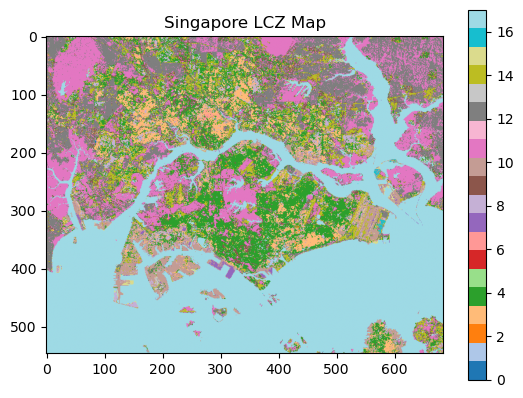

LCZ 0: 13 pixels
LCZ 1: 1066 pixels
LCZ 2: 234 pixels
LCZ 3: 17193 pixels
LCZ 4: 44631 pixels
LCZ 5: 43 pixels
LCZ 6: 1217 pixels
LCZ 7: 1484 pixels
LCZ 8: 8140 pixels
LCZ 9: 12263 pixels
LCZ 10: 16095 pixels
LCZ 11: 53015 pixels
LCZ 12: 49788 pixels
LCZ 13: 1305 pixels
LCZ 14: 20129 pixels
LCZ 15: 846 pixels
LCZ 16: 356 pixels
LCZ 17: 145646 pixels


In [31]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Path to the Singapore LCZ map
singapore_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\SINGAPORE_LCZ_map.tif"

# Open the file
with rasterio.open(singapore_path) as src:
    lcz = src.read(1)  # read the first band (LCZ)
    plt.imshow(lcz, cmap="tab20")
    plt.title("Singapore LCZ Map")
    plt.colorbar()
    plt.show()

    # Check unique values and counts
    unique, counts = np.unique(lcz, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"LCZ {u}: {c} pixels")

In [37]:
import xarray as xr
import glob

files = sorted(glob.glob(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\london*.nc"))

ds = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4")

ds.to_netcdf(r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\london_era5_2011_2025_raw.nc")

print("Combined file saved")

Combined file saved


In [41]:
import xarray as xr

# 1️⃣ Load dataset
combined_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\london_era5_2011_2025_raw.nc"
ds = xr.open_dataset(combined_path, engine="netcdf4")

# 2️⃣ Quick overview
print("✅ Dataset loaded\n")
print(ds)  # shows variables, dims, coords

# 3️⃣ More info
print("\n--- Dataset Info ---")
print(ds.info())

# 4️⃣ Check for missing values (NaNs)
print("\n--- Missing Values ---")
print(ds.isnull().sum())

# 5️⃣ Show min/max for each variable (basic sanity check)
print("\n--- Min / Max per variable ---")
for var in ds.data_vars:
    print(f"{var}: min={ds[var].min().values}, max={ds[var].max().values}")

# 6️⃣ Optional: peek at first few time steps
print("\n--- First 5 Time Steps ---")
print(ds.isel(valid_time=slice(0,5)))  # ✅ use valid_time instead of time

✅ Dataset loaded

<xarray.Dataset> Size: 132kB
Dimensions:     (valid_time: 5479, latitude: 1, longitude: 4)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude    (latitude) float64 8B 51.5
  * longitude   (longitude) float64 32B -0.5 -0.25 0.0 0.25
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 88kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-08T12:00 GRIB to CDM+CF via cfgrib-0.9.1...

--- Dataset Info ---
xarray.Dataset {
dimensions:
	valid_time = 5479 ;
	latitude = 1 ;
	longitude = 4 ;

variables:
	float32 tp(valid_time, latitude, longitude) ;
		tp:GRIB_paramId = 228 ;
		tp:GRIB_dataType = fc ;
		tp:GRIB_numberOf

In [42]:
import pandas as pd

# Assuming ds is already loaded
time_index = pd.DatetimeIndex(ds.valid_time.values)

# ✅ Quick peek: first and last dates
print("First date:", time_index.min())
print("Last date:", time_index.max())

# 1️⃣ Count of time steps per year
print("\n--- Time steps per year ---")
print(time_index.year.value_counts().sort_index())

# 2️⃣ Count of time steps per month (all years combined)
print("\n--- Time steps per month (all years) ---")
print(time_index.month.value_counts().sort_index())

# 3️⃣ Optional: MultiIndex summary (year -> month -> days)
print("\n--- Sample time structure ---")
time_summary = pd.DataFrame({'year': time_index.year, 
                             'month': time_index.month, 
                             'day': time_index.day})
print(time_summary.groupby(['year','month']).size())

First date: 2011-01-01 00:00:00
Last date: 2025-12-31 00:00:00

--- Time steps per year ---
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
2025    365
Name: count, dtype: int64

--- Time steps per month (all years) ---
1     465
2     424
3     465
4     450
5     465
6     450
7     465
8     465
9     450
10    465
11    450
12    465
Name: count, dtype: int64

--- Sample time structure ---
year  month
2011  1        31
      2        28
      3        31
      4        30
      5        31
               ..
2025  8        31
      9        30
      10       31
      11       30
      12       31
Length: 180, dtype: int64


In [59]:
import xarray as xr
import numpy as np
import pandas as pd

# 1️⃣ Load dataset
combined_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\london_era5_2011_2025_raw.nc"
ds = xr.open_dataset(combined_path, engine="netcdf4")
print("✅ Dataset loaded\n")

# 2️⃣ Dataset overview
print("--- Dataset Overview ---")
print(ds)
print("\nDimensions:", ds.dims)
print("Variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))

# 3️⃣ Time range check
print("\n--- Time Range ---")
print("First date:", ds.valid_time.min().values)
print("Last date:", ds.valid_time.max().values)

# 4️⃣ Temporal consistency
time_diff = np.diff(ds.valid_time.values.astype('datetime64[h]'))  # hourly difference
if len(time_diff) > 0:
    print("\n--- Time Step Consistency ---")
    print("Most common spacing (hours):", pd.Series(time_diff).value_counts().idxmax())
    if np.any(time_diff != time_diff[0]):
        print("⚠️ Found inconsistent time spacing!")
    else:
        print("Time spacing is consistent ✅")

# 5️⃣ Missing values
print("\n--- Missing Values ---")
for var in ds.data_vars:
    missing = np.sum(np.isnan(ds[var].values))
    print(f"{var}: {missing} missing values")

# 6️⃣ Outlier / extreme values check
for var in ds.data_vars:
    missing_val = getattr(ds[var], "GRIB_missingValue", None)
    if missing_val is not None:
        extreme = np.sum(ds[var].values >= missing_val)
        print(f"{var}: {extreme} values equal/above GRIB missing value ({missing_val})")

# 7️⃣ Duplicate timestamps
dupes = ds.valid_time.duplicated().sum().item() if hasattr(ds.valid_time, 'duplicated') else 0
print("\n--- Duplicate valid_time ---")
print(f"Duplicate timestamps: {dupes}")

# 8️⃣ Lat/Lon grid uniformity
lat_uniform = np.all(np.diff(ds.latitude.values) == np.diff(ds.latitude.values)[0]) if ds.latitude.size > 1 else True
lon_uniform = np.all(np.diff(ds.longitude.values) == np.diff(ds.longitude.values)[0]) if ds.longitude.size > 1 else True
print("\n--- Latitude / Longitude Grid Uniformity ---")
print(f"Latitude uniform? {lat_uniform}")
print(f"Longitude uniform? {lon_uniform}")

# 9️⃣ Basic statistics
print("\n--- Basic Statistics ---")
for var in ds.data_vars:
    data = ds[var].values
    print(f"{var}: min={np.nanmin(data)}, max={np.nanmax(data)}, mean={np.nanmean(data)}, std={np.nanstd(data)}")

#  🔹 Ready to process / combine later
print("\n✅ Dataset inspection complete. Ready for filtering, processing, or combining with LCZ data later.")

✅ Dataset loaded

--- Dataset Overview ---
<xarray.Dataset> Size: 132kB
Dimensions:     (valid_time: 5479, latitude: 1, longitude: 4)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude    (latitude) float64 8B 51.5
  * longitude   (longitude) float64 32B -0.5 -0.25 0.0 0.25
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 88kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-08T12:00 GRIB to CDM+CF via cfgrib-0.9.1...

Dimensions: FrozenMappingWarningOnValuesAccess({'valid_time': 5479, 'latitude': 1, 'longitude': 4})
Variables: ['tp']
Coordinates: ['number', 'latitude', 'longitude', 'valid_time']

--- Time Range ---
First d

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import pandas as pd
import glob

# Paths
raw_file = Path("../Data/Raw/london_era5_2011_2025_raw.nc")
processed_file = Path("../Data/Processed/ERA5_tp_mm.nc")

# Open the raw dataset
ds = xr.open_dataset(raw_file)

# Convert total precipitation from meters to mm
ds["tp"] = ds["tp"] * 1000

# Save to processed folder
ds.to_netcdf(processed_file)

print("Conversion complete. File saved to:", processed_file)

Conversion complete. File saved to: ..\Data\Processed\ERA5_tp_mm.nc


In [3]:
import os

file_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\NASA_Singapore_2011-2025_UTC.nc"

# Check first few bytes
with open(file_path, 'rb') as f:
    header = f.read(4)
print(header)

b'\xef\xbf\xbdH'


In [4]:
with open(r"..\Data\Raw\NASA_Tokyo_2011-2025_UTC.nc", 'rb') as f:
    print(f.read(4))

b'\xef\xbf\xbdH'


In [5]:
from pathlib import Path
import xarray as xr

# Path to the new file
raw_file = Path("../Data/Raw/POWER_Regional_Daily_20250101_20251231.nc")

# Try opening with default engine (netcdf4)
try:
    ds = xr.open_dataset(raw_file, engine="netcdf4")  # explicitly netcdf4
    print(f"\n--- Inspecting {raw_file.name} ---")
    print(ds)
    
    # Show basic info about dimensions and variables
    print("\nDimensions:", ds.dims)
    print("Variables:", list(ds.data_vars))
    
    # Check a small slice of data
    for var in ds.data_vars:
        print(f"\nSample data for '{var}':")
        print(ds[var].isel(time=slice(0,5)))  # first 5 time points

except Exception as e:
    print(f"Error opening {raw_file.name}: {e}")


--- Inspecting POWER_Regional_Daily_20250101_20251231.nc ---
<xarray.Dataset> Size: 61kB
Dimensions:      (time: 365, lat: 5, lon: 4)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2025-12-31
  * lat          (lat) float64 40B 1.0 1.5 2.0 2.5 3.0
  * lon          (lon) float64 32B 103.1 103.8 104.4 105.0
Data variables:
    PRECTOTCORR  (time, lat, lon) float64 58kB ...
Attributes: (12/22)
    acknowledgement:           The Prediction Of Worldwide Energy Resources (...
    comment:                   POWER data version 10.0.0 uses the source data...
    conventions:               CF-1.8, ACDD-1.3
    creator_email:             bradley.macpherson@nasa.gov
    creator_name:              Bradley Macpherson
    derived_from:              The data products are derived from data partne...
    ...                        ...
    publisher_name:            Paul Stackhouse
    references:                https://power.larc.nasa.gov
    source:                   

In [1]:
from pathlib import Path
import xarray as xr

# Path to your Raw folder
raw_folder = Path("../Data/Raw/")
files = sorted(raw_folder.glob("*.nc"))

# 1️⃣ List all files
print("All .nc files in the raw folder:")
for f in files:
    print(f.name)

# 2️⃣ Inspect each file briefly
for f in files:
    print(f"\n--- Inspecting {f.name} ---")
    try:
        ds = xr.open_dataset(f)
        print("Dimensions:", ds.dims)
        print("Variables:", list(ds.data_vars))
        if "time" in ds:
            print("Time range:", ds["time"].values[0], "to", ds["time"].values[-1])
        if "PRECTOTCORR" in ds:
            print("Missing values in PRECTOTCORR:", ds["PRECTOTCORR"].isnull().sum().values)
    except Exception as e:
        print("⚠️ Could not open file:", e)

All .nc files in the raw folder:
1d1783bdeac4322c8037f2179bf44bef.nc
1f395def095b56dbfda00037997b7d68.nc
1f748e7d75c37e658406b667646002e7.nc
21db4adb6d70dc12fc90af04a5c9bdfc.nc
4e5162a77cf487d247ebb79682aa77d6.nc
51542b9219237550fdb02d46a52c0c2b.nc
56cf8329119c2bb37fbc6fd4ae6cfe8a.nc
5862664870ef125c716889750ea85bb2.nc
58be3423c4b2fa8dc4e3c82aa428a0c.nc
66a1c5f5fd86e776e1ad10092b8255aa.nc
83acc3efcebf05a000e39715e3321ded.nc
a6998eca35b0a5fc206b548d07767055.nc
b4146b116da1cbcb670c7d558cf22fbf.nc
e5b59a58c90c0427aed59f0594a5cffc.nc
fb86ecf5112eacba09dabfbaa1a2d71a.nc
London_2011_02.nc
London_2011_03.nc
London_2011_04.nc
London_2011_05.nc
London_2011_06.nc
London_2011_07.nc
London_2011_08.nc
London_2011_09.nc
London_2011_10.nc
London_2011_11.nc
London_2011_12.nc
London_2012_01.nc
London_2012_02.nc
London_2012_03.nc
London_2012_04.nc
London_2012_05.nc
London_2012_06.nc
London_2012_07.nc
London_2012_08.nc
London_2012_09.nc
London_2012_10.nc
London_2012_11.nc
London_2012_12.nc
London_2013_01

In [9]:
from pathlib import Path
import xarray as xr
import re

# Raw folder path
raw_folder = Path("../Data/Raw")
output_file = raw_folder / "POWER_Singapore_2011_2025.nc"

# List all POWER files and sort by filename (chronological)
files = sorted(raw_folder.glob("POWER_Regional_Daily_*.nc"))

print("Files to combine:")
for f in files:
    print(f.name)

# Optional: check the year ranges of each file
def extract_years(filename):
    match = re.search(r"(\d{8})_(\d{8})", filename)
    if match:
        start_year = int(match.group(1)[:4])
        end_year = int(match.group(2)[:4])
        return start_year, end_year
    return None, None

print("\nYear ranges:")
for f in files:
    start, end = extract_years(f.name)
    print(f"{f.name}: {start}-{end}")

# Open all datasets and concatenate along 'time'
datasets = [xr.open_dataset(f) for f in files]
combined_ds = xr.concat(datasets, dim="time")

# Show combined dataset info
print("\n--- Combined Dataset Info ---")
print(combined_ds)
print("Time range:", combined_ds.time.min().values, "to", combined_ds.time.max().values)
print("Variables:", list(combined_ds.data_vars))

# Save combined dataset to raw folder
combined_ds.to_netcdf(output_file)
print("\nCombined file saved to:", output_file)

Files to combine:
POWER_Regional_Daily_20110101_20111231.nc
POWER_Regional_Daily_20120101_20121229.nc
POWER_Regional_Daily_20130101_20131231.nc
POWER_Regional_Daily_20140101_20141231.nc
POWER_Regional_Daily_20150101_20151231.nc
POWER_Regional_Daily_20160101_20161231.nc
POWER_Regional_Daily_20170101_20171230.nc
POWER_Regional_Daily_20180101_20181229.nc
POWER_Regional_Daily_20190101_20191231.nc
POWER_Regional_Daily_20200101_20201231.nc
POWER_Regional_Daily_20210101_20211231.nc
POWER_Regional_Daily_20220101_20221231.nc
POWER_Regional_Daily_20230101_20231230.nc
POWER_Regional_Daily_20240101_20241231.nc
POWER_Regional_Daily_20250101_20251231.nc

Year ranges:
POWER_Regional_Daily_20110101_20111231.nc: 2011-2011
POWER_Regional_Daily_20120101_20121229.nc: 2012-2012
POWER_Regional_Daily_20130101_20131231.nc: 2013-2013
POWER_Regional_Daily_20140101_20141231.nc: 2014-2014
POWER_Regional_Daily_20150101_20151231.nc: 2015-2015
POWER_Regional_Daily_20160101_20161231.nc: 2016-2016
POWER_Regional_Daily

In [10]:
import xarray as xr

file = "../Data/Raw/POWER_Singapore_2011_2025.nc"
ds = xr.open_dataset(file)

print(ds.PRECTOTCORR.attrs.get("units"))

mm/day


In [11]:
print("Number of missing values in PRECTOTCORR:", ds.PRECTOTCORR.isnull().sum().item())

Number of missing values in PRECTOTCORR: 0


In [18]:
import xarray as xr
import pandas as pd

# Load the NetCDF file
file_path = r"..\Data\Raw\POWER_Singapore_2011_2025.nc"
data = xr.open_dataset(file_path)

# See the structure of the file (dimensions, variables)
print(data)

# Usually there is a 'time' dimension
dates = pd.to_datetime(data['time'].values)

# Show first 10 and last 10 dates
print("First 10 dates:\n", dates[:10])
print("\nLast 10 dates:\n", dates[-10:])

# Total number of available dates
print("\nTotal available dates:", len(dates))

<xarray.Dataset> Size: 920kB
Dimensions:      (time: 5473, lat: 5, lon: 4)
Coordinates:
  * time         (time) datetime64[ns] 44kB 2011-01-01 2011-01-02 ... 2025-12-31
  * lat          (lat) float64 40B 1.0 1.5 2.0 2.5 3.0
  * lon          (lon) float64 32B 103.1 103.8 104.4 105.0
Data variables:
    PRECTOTCORR  (time, lat, lon) float64 876kB ...
Attributes: (12/22)
    acknowledgement:           The Prediction Of Worldwide Energy Resources (...
    comment:                   POWER data version 10.0.0 uses the source data...
    conventions:               CF-1.8, ACDD-1.3
    creator_email:             bradley.macpherson@nasa.gov
    creator_name:              Bradley Macpherson
    derived_from:              The data products are derived from data partne...
    ...                        ...
    publisher_name:            Paul Stackhouse
    references:                https://power.larc.nasa.gov
    source:                    Prediction Of Worldwide Energy Resource (POWER)
    stand

In [19]:
import xarray as xr

# If your data is an xarray Dataset
ds = xr.open_dataset(r"..\Data\Raw\POWER_Singapore_2011_2025.nc")

# Optionally sort by time (xarray usually keeps it sorted)
ds = ds.sortby("time")

# Save to processed folder
ds.to_netcdf(r"..\Data\Processed\POWER_Singapore_2011_2025_processed.nc")
print("Processed file saved!")

Processed file saved!


In [23]:
import xarray as xr
import os

# Raw folder where the Tokyo (1) files are
folder = "../Data/Raw"  # correct path

# List all the files in Raw that have "(1)" in the name
files = [os.path.join(folder, f) for f in os.listdir(folder) if "(1)" in f and f.endswith(".nc")]
files = sorted(files)  # chronological order

# Open and combine them along the time dimension
datasets = [xr.open_dataset(f) for f in files]
tokyo_combined = xr.concat(datasets, dim="time")

# Quick check
print(tokyo_combined)

# Save combined dataset into Raw folder
output_path = "../Data/Raw/POWER_Tokyo_2011_2025.nc"
tokyo_combined.to_netcdf(output_path)
print(f"Combined Tokyo file saved to: {output_path}")

<xarray.Dataset> Size: 920kB
Dimensions:      (time: 5473, lat: 5, lon: 4)
Coordinates:
  * time         (time) datetime64[ns] 44kB 2011-01-01 2011-01-02 ... 2025-12-31
  * lat          (lat) float64 40B 35.0 35.5 36.0 36.5 37.0
  * lon          (lon) float64 32B 138.1 138.8 139.4 140.0
Data variables:
    PRECTOTCORR  (time, lat, lon) float64 876kB 0.02 0.02 0.0 ... 6.52 1.04
Attributes: (12/22)
    acknowledgement:           The Prediction Of Worldwide Energy Resources (...
    comment:                   POWER data version 10.0.0 uses the source data...
    conventions:               CF-1.8, ACDD-1.3
    creator_email:             bradley.macpherson@nasa.gov
    creator_name:              Bradley Macpherson
    derived_from:              The data products are derived from data partne...
    ...                        ...
    publisher_name:            Paul Stackhouse
    references:                https://power.larc.nasa.gov
    source:                    Prediction Of Worldwide Ener

In [24]:
import xarray as xr
import numpy as np

# Load the combined Tokyo file
tokyo_file = "../Data/Raw/POWER_Tokyo_2011_2025.nc"
tokyo = xr.open_dataset(tokyo_file)

print("=== Tokyo Dataset Summary ===")
print(tokyo)

# 1️⃣ Check dimensions
print("\nDimensions:")
print(tokyo.dims)

# 2️⃣ Check coordinates
print("\nCoordinates:")
print(tokyo.coords)

# 3️⃣ Check time range and missing days
time = tokyo['time'].values
print("\nTime range:")
print(time[0], "to", time[-1])

# Total number of time steps
print("Total days:", len(time))

# Are there any missing dates? (difference between consecutive days)
date_diff = np.diff(time).astype('timedelta64[D]')
missing_days = np.where(date_diff != np.timedelta64(1, 'D'))[0]
print("Missing day indices:", missing_days)
if len(missing_days) == 0:
    print("✅ No missing days detected")
else:
    print("⚠️ There are gaps in the time series")

# 4️⃣ Check data variable and units
print("\nData variables:")
print(tokyo.data_vars)

# Example: check precipitation variable
precip = tokyo['PRECTOTCORR']
print("\nPRECTOTCORR stats:")
print("Min:", float(precip.min()))
print("Max:", float(precip.max()))
print("Mean:", float(precip.mean()))
print("NaNs:", np.isnan(precip).sum())
print("Units (if in attributes):", precip.attrs.get('units', 'No unit found'))

# 5️⃣ Check lat/lon (Tokyo coverage)
print("\nLatitude values:", tokyo['lat'].values)
print("Longitude values:", tokyo['lon'].values)

# 6️⃣ Optional: check a sample slice for sanity
print("\nSample precipitation data (first 5 days, first lat/lon):")
print(precip.isel(time=slice(0,5), lat=0, lon=0).values)

=== Tokyo Dataset Summary ===
<xarray.Dataset> Size: 920kB
Dimensions:      (time: 5473, lat: 5, lon: 4)
Coordinates:
  * time         (time) datetime64[ns] 44kB 2011-01-01 2011-01-02 ... 2025-12-31
  * lat          (lat) float64 40B 35.0 35.5 36.0 36.5 37.0
  * lon          (lon) float64 32B 138.1 138.8 139.4 140.0
Data variables:
    PRECTOTCORR  (time, lat, lon) float64 876kB ...
Attributes: (12/22)
    acknowledgement:           The Prediction Of Worldwide Energy Resources (...
    comment:                   POWER data version 10.0.0 uses the source data...
    conventions:               CF-1.8, ACDD-1.3
    creator_email:             bradley.macpherson@nasa.gov
    creator_name:              Bradley Macpherson
    derived_from:              The data products are derived from data partne...
    ...                        ...
    publisher_name:            Paul Stackhouse
    references:                https://power.larc.nasa.gov
    source:                    Prediction Of Worldwid

In [25]:
import xarray as xr
import pandas as pd
import numpy as np

# Load your combined Tokyo dataset
tokyo_ds = xr.open_dataset("../Data/Raw/POWER_Tokyo_2011_2025.nc")

# Create a full daily time index from start to end
full_time = pd.date_range(start=tokyo_ds.time.min().values,
                          end=tokyo_ds.time.max().values, freq='D')

# Reindex to include missing days (they will be NaN)
tokyo_ds = tokyo_ds.reindex(time=full_time)

# Interpolate missing values linearly
tokyo_ds['PRECTOTCORR'] = tokyo_ds['PRECTOTCORR'].interpolate_na(dim='time', method='linear')

# Check if any NaNs remain
print("Remaining NaNs:", np.isnan(tokyo_ds['PRECTOTCORR']).sum().values)

# Save the fixed dataset to Processed
tokyo_ds.to_netcdf("../Data/Processed/POWER_Tokyo_2011_2025.nc")
print("Fixed Tokyo dataset saved to Processed folder!")

Remaining NaNs: 0
Fixed Tokyo dataset saved to Processed folder!


In [26]:
import xarray as xr
import numpy as np

# Load the combined Singapore file
singapore_file = "../Data/Raw/POWER_Singapore_2011_2025.nc"
singapore = xr.open_dataset(singapore_file)

print("=== Singapore Dataset Summary ===")
print(singapore)

# 1️⃣ Check dimensions
print("\nDimensions:")
print(singapore.dims)

# 2️⃣ Check coordinates
print("\nCoordinates:")
print(singapore.coords)

# 3️⃣ Check time range and missing days
time = singapore['time'].values
print("\nTime range:")
print(time[0], "to", time[-1])

# Total number of time steps
print("Total days:", len(time))

# Are there any missing dates? (difference between consecutive days)
date_diff = np.diff(time).astype('timedelta64[D]')
missing_days = np.where(date_diff != np.timedelta64(1, 'D'))[0]
print("Missing day indices:", missing_days)
if len(missing_days) == 0:
    print("✅ No missing days detected")
else:
    print("⚠️ There are gaps in the time series")

# 4️⃣ Check data variable and units
print("\nData variables:")
print(singapore.data_vars)

# Example: check precipitation variable
precip = singapore['PRECTOTCORR']
print("\nPRECTOTCORR stats:")
print("Min:", float(precip.min()))
print("Max:", float(precip.max()))
print("Mean:", float(precip.mean()))
print("NaNs:", np.isnan(precip).sum())
print("Units (if in attributes):", precip.attrs.get('units', 'No unit found'))

# 5️⃣ Check lat/lon (Singapore coverage)
print("\nLatitude values:", singapore['lat'].values)
print("Longitude values:", singapore['lon'].values)

# 6️⃣ Optional: check a sample slice for sanity
print("\nSample precipitation data (first 5 days, first lat/lon):")
print(precip.isel(time=slice(0,5), lat=0, lon=0).values)

=== Singapore Dataset Summary ===
<xarray.Dataset> Size: 920kB
Dimensions:      (time: 5473, lat: 5, lon: 4)
Coordinates:
  * time         (time) datetime64[ns] 44kB 2011-01-01 2011-01-02 ... 2025-12-31
  * lat          (lat) float64 40B 1.0 1.5 2.0 2.5 3.0
  * lon          (lon) float64 32B 103.1 103.8 104.4 105.0
Data variables:
    PRECTOTCORR  (time, lat, lon) float64 876kB ...
Attributes: (12/22)
    acknowledgement:           The Prediction Of Worldwide Energy Resources (...
    comment:                   POWER data version 10.0.0 uses the source data...
    conventions:               CF-1.8, ACDD-1.3
    creator_email:             bradley.macpherson@nasa.gov
    creator_name:              Bradley Macpherson
    derived_from:              The data products are derived from data partne...
    ...                        ...
    publisher_name:            Paul Stackhouse
    references:                https://power.larc.nasa.gov
    source:                    Prediction Of Worldwide

In [27]:
import xarray as xr

# Load your combined raw Tokyo dataset
tokyo_ds = xr.open_dataset("../Data/Raw/POWER_Tokyo_2011_2025.nc")

# Save it as-is to the Processed folder
tokyo_ds.to_netcdf("../Data/Processed/POWER_Tokyo_2011_2025.nc")

print("Raw Tokyo dataset copied to Processed folder without any changes!")

Raw Tokyo dataset copied to Processed folder without any changes!


In [2]:
import xarray as xr
import os

# Folder where the files are
folder = "../Data/Raw"

# Select only New York files
files = [os.path.join(folder, f) for f in os.listdir(folder) if f.startswith("New_York") and f.endswith(".nc")]

# Sort them so time order is correct
files = sorted(files)

print("Total files found:", len(files))

# Combine along time
ny_ds = xr.open_mfdataset(files, combine="by_coords")

# Save combined dataset
output_path = "../Data/Raw/POWER_NewYork_2011_2025.nc"
ny_ds.to_netcdf(output_path)

print("Combined New York dataset saved to:", output_path)

Total files found: 98


C:\Users\janaa\AppData\Local\Temp\ipykernel_23792\903380617.py:16: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  ny_ds = xr.open_mfdataset(files, combine="by_coords")


Combined New York dataset saved to: ../Data/Raw/POWER_NewYork_2011_2025.nc


In [4]:
import xarray as xr
import numpy as np

ny_file = "../Data/Raw/POWER_NewYork_2011_2025.nc"
ny = xr.open_dataset(ny_file)

print("=== New York Dataset Summary ===")
print(ny)

# 1️⃣ Dimensions
print("\nDimensions:")
print(ny.dims)

# 2️⃣ Coordinates
print("\nCoordinates:")
print(ny.coords)

# 3️⃣ Time range
time = ny['valid_time'].values

print("\nTime range:")
print(time[0], "to", time[-1])
print("Total days:", len(time))

date_diff = np.diff(time).astype('timedelta64[D]')
missing_days = np.where(date_diff != np.timedelta64(1,'D'))[0]

print("Missing day indices:", missing_days)

if len(missing_days) == 0:
    print("✅ No missing days detected")
else:
    print("⚠️ There are gaps in the time series")

# 4️⃣ Variable check
print("\nData variables:")
print(ny.data_vars)

precip = ny['tp']

print("\nPrecipitation stats:")
print("Min:", float(precip.min()))
print("Max:", float(precip.max()))
print("Mean:", float(precip.mean()))
print("NaNs:", np.isnan(precip).sum())

# 5️⃣ Lat/lon check
print("\nLatitude values:", ny['latitude'].values[:10], "...")
print("Longitude values:", ny['longitude'].values)

# 6️⃣ Sample values
print("\nSample precipitation data:")
print(precip.isel(valid_time=slice(0,5), latitude=0, longitude=0).values)

=== New York Dataset Summary ===
<xarray.Dataset> Size: 21MB
Dimensions:     (valid_time: 5479, latitude: 326, longitude: 3)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude    (latitude) float64 3kB -40.5 -40.25 -40.0 ... 40.25 40.5 40.75
  * longitude   (longitude) float64 24B -74.25 -74.0 -73.75
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 21MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-08T16:41 GRIB to CDM+CF via cfgrib-0.9.1...

Dimensions:
FrozenMappingWarningOnValuesAccess({'valid_time': 5479, 'latitude': 326, 'longitude': 3})

Coordinates:
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 44kB 201

In [5]:
ny_point = ny.sel(latitude=40.75, longitude=-74.0, method="nearest")
print(ny_point['tp'].isel(valid_time=slice(0,10)).values)

[0.0000000e+00 1.6655922e-03 3.3473969e-04 0.0000000e+00 9.5367432e-07
 1.6212463e-05 2.9163361e-03 1.0151863e-03 3.3617020e-04 0.0000000e+00]


In [8]:
import xarray as xr

# Load
ny = xr.open_dataset("../Data/Raw/POWER_NewYork_2011_2025.nc")

# Crop to NYC region
ny_crop = ny.sel(
    latitude=slice(41, 40),
    longitude=slice(-74.5, -73.5)
)

# Convert precipitation to mm
ny_crop["tp"] = ny_crop["tp"] * 1000

# Prepare encoding to avoid NetCDF errors
encoding = {var: {"dtype": "float32"} for var in ny_crop.data_vars}
# Explicitly also encode coordinates
for coord in ny_crop.coords:
    encoding[coord] = {"dtype": "float64"}

# Save safely
ny_crop.to_netcdf("../Data/Processed/POWER_NewYork_2011_2025.nc", encoding=encoding)

print("✅ New York dataset successfully saved to Processed!")

✅ New York dataset successfully saved to Processed!


In [1]:
import os

# Path to your Processed folder
processed_folder = "../Data/Processed"

# List all files in the folder
files = os.listdir(processed_folder)

# Sort them for easier reading
files = sorted(files)

print("Files currently in Processed folder:")
for f in files:
    print(f)

Files currently in Processed folder:
.ipynb_checkpoints
London_2011_2025_processed.nc
London_LCZ.tif
New_York_2011_2025_processed.nc
New_York_LCZ.tif
POWER_Singapore_2011_2025_processed.nc
POWER_Tokyo_2011_2025_processed.nc
SINGAPORE_LCZ.tif
Tokyo_LCZ.tif


In [1]:
import xarray as xr
import rioxarray  # for reading .tif
import os

# Paths
processed_folder = "../Data/Processed/"

# City file mapping: rainfall NC file and LCZ tif file
cities = {
    "New_York": ["New_York_2011_2025_processed.nc", "New_York_LCZ.tif"],
    "Tokyo": ["POWER_Tokyo_2011_2025_processed.nc", "Tokyo_LCZ.tif"],
    "Singapore": ["POWER_Singapore_2011_2025_processed.nc", "SINGAPORE_LCZ.tif"],
    "London": ["London_2011_2025_processed.nc", "London_LCZ.tif"]
}

for city, files in cities.items():
    rain_file = os.path.join(processed_folder, files[0])
    lcz_file = os.path.join(processed_folder, files[1])
    
    print(f"Processing {city}...")
    
    # 1️⃣ Load rainfall dataset
    rain_ds = xr.open_dataset(rain_file)
    
    # 2️⃣ Load LCZ raster and convert to xarray DataArray
    lcz_da = rioxarray.open_rasterio(lcz_file)
    
    # Remove the band dimension if present (common in GeoTIFFs)
    if "band" in lcz_da.dims:
        lcz_da = lcz_da.squeeze("band", drop=True)
    
    # 3️⃣ Rename LCZ coords to match rainfall for merging
    lcz_da = lcz_da.rename({"x": "lon", "y": "lat"})
    
    # Optional: make LCZ coordinates match rainfall grid if needed
    # (resampling/interpolation can be added here if necessary)
    
    # 4️⃣ Merge rainfall + LCZ
    combined_ds = xr.merge([rain_ds, lcz_da.to_dataset(name="LCZ")], compat='override')
    
    # 5️⃣ Save new combined file
    combined_file = os.path.join(processed_folder, f"{city}_Combined.nc")
    combined_ds.to_netcdf(combined_file)
    
    print(f"✅ {city} combined dataset saved to: {combined_file}\n")

Processing New_York...
✅ New_York combined dataset saved to: ../Data/Processed/New_York_Combined.nc

Processing Tokyo...


ValueError: cannot select a dimension to squeeze out which has length greater than one

In [18]:
import xarray as xr
import rioxarray
import os

# Paths
processed_folder = "../Data/Processed/"
rain_file = os.path.join(processed_folder, "London_2011_2025_processed.nc")
lcz_file = os.path.join(processed_folder, "London_LCZ.tif")
combined_file = os.path.join(processed_folder, "London_Combined.nc")

print("Processing London...")

# Load rainfall
rain_ds = xr.open_dataset(rain_file)

# Load LCZ
lcz_da = rioxarray.open_rasterio(lcz_file, masked=True)

# Remove band dimension if present
if "band" in lcz_da.dims and lcz_da.sizes["band"] == 1:
    lcz_da = lcz_da.squeeze("band", drop=True)

# Rename coords to match rainfall
lcz_da = lcz_da.rename({"x": "lon", "y": "lat"})

# ⚡ Give the LCZ layer a name so it can merge
lcz_da.name = "LCZ"

# Merge
combined_ds = xr.merge([rain_ds, lcz_da])

# Save
combined_ds.to_netcdf(combined_file)
print(f"✅ London combined dataset saved to: {combined_file}")

Processing London...
✅ London combined dataset saved to: ../Data/Processed/London_Combined.nc


Processing Tokyo...


CRSError: Missing dst_crs.

In [15]:
# Check if rainfall dataset has CRS
print(rain_ds.rio.crs)

None


In [20]:
rain_ds.rio.write_crs("EPSG:4326", inplace=True)

<xarray.Dataset> Size: 132kB
Dimensions:      (valid_time: 5479, latitude: 1, longitude: 4)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude     (latitude) float64 8B 51.5
  * longitude    (longitude) float64 32B -0.5 -0.25 0.0 0.25
    number       int64 8B ...
    spatial_ref  int64 8B 0
Data variables:
    tp           (valid_time, latitude, longitude) float32 88kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-08T12:00 GRIB to CDM+CF via cfgrib-0.9.1...

In [21]:
print(rain_ds.rio.crs)
print(rain_ds.rio.transform())

EPSG:4326
| 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|


In [5]:
import xarray as xr

ny = xr.open_dataset("../Data/Processed/New_York_Combined.nc")
lon = xr.open_dataset("../Data/Processed/London_Combined.nc")

print("NEW YORK DATASET")
print(ny)

print("\nLONDON DATASET")
print(lon)

NEW YORK DATASET
<xarray.Dataset> Size: 2MB
Dimensions:      (valid_time: 5479, latitude: 0, longitude: 3, lat: 368,
                  lon: 553)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude     (latitude) float64 0B 
  * longitude    (longitude) float64 24B -74.25 -74.0 -73.75
  * lat          (lat) float64 3kB 40.9 40.9 40.9 40.9 ... 40.5 40.5 40.5 40.5
  * lon          (lon) float64 4kB -74.3 -74.3 -74.3 -74.3 ... -73.7 -73.7 -73.7
    number       float64 8B ...
Data variables:
    tp           (valid_time, latitude, longitude) float32 0B ...
    spatial_ref  int64 8B ...
    LCZ          (lat, lon) float64 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-08T16:4

In [6]:
import xarray as xr

ny = xr.open_dataset("../Data/Processed/New_York_Combined.nc")
lon = xr.open_dataset("../Data/Processed/London_Combined.nc")

print("NEW YORK DATASET")
print(ny)

print("\nLONDON DATASET")
print(lon)

NEW YORK DATASET
<xarray.Dataset> Size: 2MB
Dimensions:      (valid_time: 5479, latitude: 0, longitude: 3, lat: 368,
                  lon: 553)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude     (latitude) float64 0B 
  * longitude    (longitude) float64 24B -74.25 -74.0 -73.75
  * lat          (lat) float64 3kB 40.9 40.9 40.9 40.9 ... 40.5 40.5 40.5 40.5
  * lon          (lon) float64 4kB -74.3 -74.3 -74.3 -74.3 ... -73.7 -73.7 -73.7
    number       float64 8B ...
Data variables:
    tp           (valid_time, latitude, longitude) float32 0B ...
    spatial_ref  int64 8B ...
    LCZ          (lat, lon) float64 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-08T16:4

In [7]:
print(ny["LCZ"])
print(lon["LCZ"])

<xarray.DataArray 'LCZ' (lat: 368, lon: 553)> Size: 2MB
[203504 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 3kB 40.9 40.9 40.9 40.9 40.9 ... 40.5 40.5 40.5 40.5
  * lon      (lon) float64 4kB -74.3 -74.3 -74.3 -74.3 ... -73.7 -73.7 -73.7
    number   float64 8B ...
Attributes:
    AREA_OR_POINT:  Area
    grid_mapping:   spatial_ref
<xarray.DataArray 'LCZ' (lat: 365, lon: 611)> Size: 2MB
[223015 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 3kB 3.221e+06 3.221e+06 ... 3.185e+06 3.185e+06
  * lon      (lon) float64 5kB 3.592e+06 3.592e+06 ... 3.653e+06 3.653e+06
    number   int64 8B ...
Attributes:
    AREA_OR_POINT:  Area
    grid_mapping:   spatial_ref


In [10]:
import xarray as xr

# Path to raw data
raw_path = "../Data/Raw/POWER_NewYork_2011_2025.nc"

# Open the raw dataset
raw_ny = xr.open_dataset(raw_path)

# Check what variables exist
print("Variables in raw NY data:", list(raw_ny.data_vars))

# Check tp min/max
if "tp" in raw_ny.data_vars:
    tp_values = raw_ny["tp"].values
    if tp_values.size == 0:
        print("TP exists but is empty!")
    else:
        print("TP exists and has values!")
        print("TP min:", tp_values.min(), "TP max:", tp_values.max())
else:
    print("TP variable is missing in the raw data!")

Variables in raw NY data: ['tp']
TP exists and has values!
TP min: nan TP max: nan


In [11]:
import numpy as np

# Find locations with non-NaN values
valid_mask = ~np.isnan(raw_ny["tp"].values)
print("Any valid TP values?", valid_mask.any())

# Optional: check how many are valid
print("Number of valid TP values:", valid_mask.sum())

# Quick check: look at first few valid entries
tp_flat = raw_ny["tp"].values.flatten()
print("First 10 non-NaN TP values:", tp_flat[~np.isnan(tp_flat)][:10])

Any valid TP values? True
Number of valid TP values: 387654
First 10 non-NaN TP values: [0.0000000e+00 4.7683716e-07 1.4305115e-06 0.0000000e+00 0.0000000e+00
 0.0000000e+00 1.2922287e-03 3.5557747e-03 4.7154427e-03 1.5239716e-03]


In [12]:
import rasterio

lcz_path = "../Data/Processed/New_York_LCZ.tif"

with rasterio.open(lcz_path) as src:
    print("LCZ width, height:", src.width, src.height)
    print("LCZ crs:", src.crs)
    print("LCZ bounds:", src.bounds)
    
    lcz_data = src.read(1)  # Read the first (and usually only) band
    print("LCZ unique values:", sorted(set(lcz_data.flatten())))

LCZ width, height: 553 368
LCZ crs: EPSG:4326
LCZ bounds: BoundingBox(left=-74.29999999999998, bottom=40.500402067078916, right=-73.69951723667019, top=40.900000000000006)
LCZ unique values: [np.int16(0), np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(8), np.int16(10), np.int16(11), np.int16(12), np.int16(14), np.int16(15), np.int16(16), np.int16(17)]


In [24]:
import xarray as xr
import rioxarray
import numpy as np
import os

# Paths
raw_tp_path = "../Data/Raw/POWER_NewYork_2011_2025.nc"
lcz_path = "../Data/Processed/New_York_LCZ.tif"
# Use a new filename to avoid permission issues
combined_save_path = "../Data/Processed/New_York_Combined_v2.nc"

# 1️⃣ Load raw TP data
print("Loading raw TP data...")
tp_ds = xr.open_dataset(raw_tp_path)
print(tp_ds)

# 2️⃣ Convert TP to mm/day if needed
print("Converting TP to mm/day...")
tp_ds["tp"] = tp_ds["tp"] * 1000  # m -> mm

# 3️⃣ Load LCZ raster
print("Loading LCZ data...")
lcz_da = rioxarray.open_rasterio(lcz_path, masked=True).squeeze("band", drop=True)
print(lcz_da)

# 4️⃣ Ensure LCZ has a proper CRS
if lcz_da.rio.crs is None:
    print("Assigning EPSG:4326 CRS to LCZ...")
    lcz_da = lcz_da.rio.write_crs("EPSG:4326", inplace=True)

# 5️⃣ Rename LCZ dims to match TP
lcz_da = lcz_da.rename({"y": "lat", "x": "lon"})

# 6️⃣ Interpolate LCZ to TP lat/lon grid
print("Interpolating LCZ to match TP grid...")
lcz_da_aligned = lcz_da.interp(
    lon=tp_ds.longitude,
    lat=tp_ds.latitude
)

# 7️⃣ Convert LCZ to float32 for memory efficiency
lcz_da_aligned = lcz_da_aligned.astype(np.float32)

# 8️⃣ Align TP to LCZ (flatten TP over lat/lon if needed)
tp_aligned = tp_ds["tp"]

# 9️⃣ Create combined dataset
combined_ds = xr.Dataset({
    "tp": tp_aligned,
    "LCZ": lcz_da_aligned
})

# 🔟 Save combined dataset
print("Saving combined dataset as a new file to avoid overwrite issues...")
combined_ds.to_netcdf(combined_save_path, mode="w")
print("✅ Combined dataset saved at:", combined_save_path)

Loading raw TP data...
<xarray.Dataset> Size: 21MB
Dimensions:     (valid_time: 5479, latitude: 326, longitude: 3)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude    (latitude) float64 3kB -40.5 -40.25 -40.0 ... 40.25 40.5 40.75
  * longitude   (longitude) float64 24B -74.25 -74.0 -73.75
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 21MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-08T16:41 GRIB to CDM+CF via cfgrib-0.9.1...
Converting TP to mm/day...
Loading LCZ data...
<xarray.DataArray (y: 368, x: 553)> Size: 814kB
[203504 values with dtype=float32]
Coordinates:
  * y            (y) float64 3kB 40.9 40.9 40.9 4

✅ Loaded combined dataset:
<xarray.Dataset> Size: 21MB
Dimensions:      (valid_time: 5479, latitude: 326, longitude: 3)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude     (latitude) float64 3kB -40.5 -40.25 -40.0 ... 40.25 40.5 40.75
    lat          (latitude) float64 3kB ...
  * longitude    (longitude) float64 24B -74.25 -74.0 -73.75
    lon          (longitude) float64 24B ...
    number       int64 8B ...
    spatial_ref  int64 8B ...
Data variables:
    tp           (valid_time, latitude, longitude) float32 21MB ...
    LCZ          (latitude, longitude) float32 4kB ...

Dataset dimensions:
FrozenMappingWarningOnValuesAccess({'valid_time': 5479, 'latitude': 326, 'longitude': 3})

Coordinates:
latitude: [-40.5  -40.25 -40.   -39.75 -39.5 ] ... [39.75 40.   40.25 40.5  40.75]
longitude: [-74.25 -74.   -73.75] ... [-74.25 -74.   -73.75]
valid_time: ['2011-01-01T00:00:00.000000000' '2011-01-02T00:00:00.000000000'
 '2011-01-03T00:

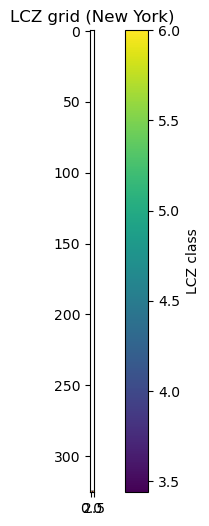

In [26]:
import xarray as xr
import numpy as np

# Load combined dataset
combined_path = "../Data/Processed/New_York_Combined_v2.nc"
combined_ds = xr.open_dataset(combined_path)
print("✅ Loaded combined dataset:")
print(combined_ds)

# 1️⃣ Check dimensions
print("\nDataset dimensions:")
print(combined_ds.dims)

# 2️⃣ Check coordinates safely
print("\nCoordinates:")
for coord in combined_ds.coords:
    val = combined_ds.coords[coord].values
    # If 1D array, show first 5 and last 5
    if val.ndim == 1:
        print(f"{coord}: {val[:5]} ... {val[-5:]}")
    # If scalar/0D, just show the value
    else:
        print(f"{coord}: {val}")

# 3️⃣ Check TP variable
tp = combined_ds["tp"]
print("\nTP info:")
print(tp)
print("TP min:", np.nanmin(tp.values))
print("TP max:", np.nanmax(tp.values))
print("TP number of valid (non-NaN) values:", np.count_nonzero(~np.isnan(tp.values)))

# 4️⃣ Check LCZ variable
lcz = combined_ds["LCZ"]
print("\nLCZ info:")
print(lcz)
print("LCZ unique values:", np.unique(lcz.values))
print("LCZ shape:", lcz.shape)

# 5️⃣ Optional: Quick visual check of LCZ
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,6))
    plt.imshow(lcz.values, origin="upper")
    plt.title("LCZ grid (New York)")
    plt.colorbar(label="LCZ class")
    plt.show()
except ImportError:
    print("matplotlib not installed, skipping LCZ visualization.")

In [27]:
import xarray as xr
import numpy as np
import os

# Paths
combined_path = "../Data/Processed/New_York_Combined_v2.nc"
flattened_save_path = "../Data/Processed/New_York_Flattened.nc"

# 1️⃣ Load combined dataset
print("Loading combined dataset...")
combined_ds = xr.open_dataset(combined_path)
print(combined_ds)

# 2️⃣ Flatten TP and LCZ
print("Flattening dataset...")

# Get coordinate grids
lat = combined_ds["latitude"].values
lon = combined_ds["longitude"].values

# Flatten lat/lon grids
lat_grid, lon_grid = np.meshgrid(lat, lon, indexing="ij")
lat_flat = lat_grid.flatten()
lon_flat = lon_grid.flatten()

# Flatten LCZ
lcz_flat = combined_ds["LCZ"].values.flatten()

# Flatten TP over time
tp_flat_list = []
for t in range(len(combined_ds.valid_time)):
    tp_day = combined_ds["tp"].isel(valid_time=t).values.flatten()
    tp_flat_list.append(tp_day)
tp_flat = np.array(tp_flat_list)  # shape: (time, grid_points)

# Optional: reshape so each row is a grid cell at a given time
# Columns: valid_time, lat, lon, TP, LCZ
times_repeated = np.repeat(combined_ds.valid_time.values, len(lat_flat))
lat_repeated = np.tile(lat_flat, len(combined_ds.valid_time))
lon_repeated = np.tile(lon_flat, len(combined_ds.valid_time))
tp_flat_all = tp_flat.flatten()
lcz_repeated = np.tile(lcz_flat, len(combined_ds.valid_time))

# Create flattened xarray dataset
flattened_ds = xr.Dataset({
    "tp": (("sample"), tp_flat_all),
    "LCZ": (("sample"), lcz_repeated),
    "latitude": (("sample"), lat_repeated),
    "longitude": (("sample"), lon_repeated),
    "valid_time": (("sample"), times_repeated)
})

# 3️⃣ Save flattened dataset
if os.path.exists(flattened_save_path):
    print("Overwriting existing flattened file...")
flattened_ds.to_netcdf(flattened_save_path, mode="w")
print("✅ Flattened dataset saved at:", flattened_save_path)

Loading combined dataset...
<xarray.Dataset> Size: 21MB
Dimensions:      (valid_time: 5479, latitude: 326, longitude: 3)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude     (latitude) float64 3kB -40.5 -40.25 -40.0 ... 40.25 40.5 40.75
    lat          (latitude) float64 3kB ...
  * longitude    (longitude) float64 24B -74.25 -74.0 -73.75
    lon          (longitude) float64 24B ...
    number       int64 8B ...
    spatial_ref  int64 8B ...
Data variables:
    tp           (valid_time, latitude, longitude) float32 21MB ...
    LCZ          (latitude, longitude) float32 4kB ...
Flattening dataset...
✅ Flattened dataset saved at: ../Data/Processed/New_York_Flattened.nc


In [28]:
import xarray as xr
import numpy as np

# Path to flattened dataset
flattened_path = "../Data/Processed/New_York_Flattened.nc"

# 1️⃣ Load flattened dataset
flattened_ds = xr.open_dataset(flattened_path)
print("✅ Loaded flattened dataset:")

# 2️⃣ Quick overview
print(flattened_ds)

# 3️⃣ Check first 5 and last 5 entries of each variable
for var in flattened_ds.data_vars:
    data = flattened_ds[var].values
    print(f"\n{var} sample values:")
    print("First 5:", data[:5])
    print("Last 5:", data[-5:])

# 4️⃣ Check dataset shape and NaNs
print("\nDataset shape:", {var: flattened_ds[var].shape for var in flattened_ds.data_vars})
for var in flattened_ds.data_vars:
    nan_count = np.isnan(flattened_ds[var].values).sum()
    print(f"{var} NaN count: {nan_count}")

✅ Loaded flattened dataset:
<xarray.Dataset> Size: 171MB
Dimensions:     (sample: 5358462)
Dimensions without coordinates: sample
Data variables:
    tp          (sample) float32 21MB ...
    LCZ         (sample) float32 21MB ...
    latitude    (sample) float64 43MB ...
    longitude   (sample) float64 43MB ...
    valid_time  (sample) datetime64[ns] 43MB ...

tp sample values:
First 5: [nan nan nan nan nan]
Last 5: [0.02670288 0.01716614 0.04434586 0.03051758 0.02145767]

LCZ sample values:
First 5: [nan nan nan nan nan]
Last 5: [      nan       nan 6.        3.4382677 6.       ]

latitude sample values:
First 5: [-40.5  -40.5  -40.5  -40.25 -40.25]
Last 5: [40.5  40.5  40.75 40.75 40.75]

longitude sample values:
First 5: [-74.25 -74.   -73.75 -74.25 -74.  ]
Last 5: [-74.   -73.75 -74.25 -74.   -73.75]

valid_time sample values:
First 5: ['2011-01-01T00:00:00.000000000' '2011-01-01T00:00:00.000000000'
 '2011-01-01T00:00:00.000000000' '2011-01-01T00:00:00.000000000'
 '2011-01-01T00:0

In [30]:
import xarray as xr
import rioxarray
import numpy as np
import os

# Paths
raw_tp_path = "../Data/Raw/london_era5_2011_2025_raw.nc"
lcz_path = "../Data/Processed/London_LCZ.tif"
combined_save_path = "../Data/Processed/London_Combined.nc"
flattened_save_path = "../Data/Processed/London_Combined_Flattened.nc"

# 1️⃣ Load raw TP data
print("Loading raw TP data...")
tp_ds = xr.open_dataset(raw_tp_path)
print(tp_ds)

# 2️⃣ Convert TP to mm/day if needed
print("Converting TP to mm/day...")
tp_ds["tp"] = tp_ds["tp"] * 1000  # m -> mm

# 3️⃣ Load LCZ raster
print("Loading LCZ data...")
lcz_da = rioxarray.open_rasterio(lcz_path, masked=True).squeeze("band", drop=True)
print(lcz_da)

# 4️⃣ Ensure LCZ has a proper CRS
if lcz_da.rio.crs is None:
    print("Assigning EPSG:4326 CRS to LCZ...")
    lcz_da = lcz_da.rio.write_crs("EPSG:4326", inplace=True)
else:
    # Reproject to EPSG:4326 if needed
    if lcz_da.rio.crs.to_string() != "EPSG:4326":
        print("Reprojecting LCZ to EPSG:4326...")
        lcz_da = lcz_da.rio.reproject("EPSG:4326")

# 5️⃣ Rename LCZ dims to match TP
lcz_da = lcz_da.rename({"y": "lat", "x": "lon"})

# 6️⃣ Interpolate LCZ to TP lat/lon grid
print("Interpolating LCZ to match TP grid...")
lcz_da_aligned = lcz_da.interp(
    lon=tp_ds.longitude,
    lat=tp_ds.latitude
)

# 7️⃣ Convert LCZ to float32 for memory efficiency
lcz_da_aligned = lcz_da_aligned.astype(np.float32)

# 8️⃣ Align TP to LCZ (flatten TP over lat/lon if needed)
tp_aligned = tp_ds["tp"]

# 9️⃣ Create combined dataset
combined_ds = xr.Dataset({
    "tp": tp_aligned,
    "LCZ": lcz_da_aligned
})

# 🔟 Save combined dataset
if os.path.exists(combined_save_path):
    print("Overwriting existing combined file...")
combined_ds.to_netcdf(combined_save_path, mode="w")
print("✅ Combined dataset saved at:", combined_save_path)

# 1️⃣1️⃣ Flatten dataset for ML
print("Flattening dataset for ML...")
flat_ds = combined_ds.stack(sample=("valid_time", "latitude", "longitude"))

# Reset MultiIndex so NetCDF can handle it
flat_ds = flat_ds.reset_index(["valid_time", "latitude", "longitude"])

# Save flattened version
flat_ds.to_netcdf(flattened_save_path, mode="w")
print("✅ Flattened dataset saved at:", flattened_save_path)

Loading raw TP data...
<xarray.Dataset> Size: 132kB
Dimensions:     (valid_time: 5479, latitude: 1, longitude: 4)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude    (latitude) float64 8B 51.5
  * longitude   (longitude) float64 32B -0.5 -0.25 0.0 0.25
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 88kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-08T12:00 GRIB to CDM+CF via cfgrib-0.9.1...
Converting TP to mm/day...
Loading LCZ data...
<xarray.DataArray (y: 365, x: 611)> Size: 892kB
[223015 values with dtype=float32]
Coordinates:
  * y            (y) float64 3kB 3.221e+06 3.221e+06 ... 3.185e+06 3.185e+06
  * x    

In [31]:
import xarray as xr
import numpy as np

# Paths
combined_path = "../Data/Processed/London_Combined.nc"
flattened_path = "../Data/Processed/London_Combined_Flattened.nc"

# Load datasets
combined_ds = xr.open_dataset(combined_path)
flat_ds = xr.open_dataset(flattened_path)

# ✅ 1. Quick overview
print("Combined dataset overview:")
print(combined_ds)
print("\nFlattened dataset overview:")
print(flat_ds)

# 2. Check TP and LCZ values
print("\nTP variable:")
print(combined_ds["tp"])
print("TP min:", float(np.nanmin(combined_ds["tp"].values)))
print("TP max:", float(np.nanmax(combined_ds["tp"].values)))
print("TP valid count:", int(np.count_nonzero(~np.isnan(combined_ds["tp"].values))))

print("\nLCZ variable:")
print(combined_ds["LCZ"])
print("LCZ unique values:", np.unique(combined_ds["LCZ"].values[~np.isnan(combined_ds["LCZ"].values)]))
print("LCZ shape:", combined_ds["LCZ"].shape)

# 3. Flattened dataset NaN check
for var in ["tp", "LCZ", "latitude", "longitude", "valid_time"]:
    arr = flat_ds[var].values
    nan_count = np.count_nonzero(np.isnan(arr)) if np.issubdtype(arr.dtype, np.floating) else 0
    print(f"{var} NaN count: {nan_count}")

Combined dataset overview:
<xarray.Dataset> Size: 132kB
Dimensions:      (valid_time: 5479, latitude: 1, longitude: 4)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 44kB 2011-01-01 ... 2025-12-31
  * latitude     (latitude) float64 8B 51.5
    lat          (latitude) float64 8B ...
  * longitude    (longitude) float64 32B -0.5 -0.25 0.0 0.25
    lon          (longitude) float64 32B ...
    number       int64 8B ...
    spatial_ref  int64 8B ...
Data variables:
    tp           (valid_time, latitude, longitude) float32 88kB ...
    LCZ          (latitude, longitude) float32 16B ...

Flattened dataset overview:
<xarray.Dataset> Size: 1MB
Dimensions:      (sample: 21916)
Coordinates:
    lon          (sample) float64 175kB ...
    lat          (sample) float64 175kB ...
    valid_time   (sample) datetime64[ns] 175kB ...
    latitude     (sample) float64 175kB ...
    longitude    (sample) float64 175kB ...
    number       int64 8B ...
    spatial_ref  int64 8B ...
Dimensions 

In [32]:
import xarray as xr
import os

# Paths
flattened_path = "../Data/Processed/London_Combined_Flattened.nc"
flattened_mm_path = "../Data/Processed/London_Combined_Flattened_mm.nc"

# 1️⃣ Load flattened dataset
ds = xr.open_dataset(flattened_path)
print("Loaded flattened London dataset.")

# 2️⃣ Convert TP to mm/day
ds["tp"] = ds["tp"] * 1000  # m -> mm
ds["tp"].attrs["units"] = "mm/day"

# 3️⃣ Save as new file
if os.path.exists(flattened_mm_path):
    print("Overwriting existing file:", flattened_mm_path)
ds.to_netcdf(flattened_mm_path, mode="w")
print("✅ Flattened London TP converted to mm/day and saved at:", flattened_mm_path)

Loaded flattened London dataset.
✅ Flattened London TP converted to mm/day and saved at: ../Data/Processed/London_Combined_Flattened_mm.nc


In [33]:
import xarray as xr

# Load the flattened dataset in mm
flattened_mm_path = "../Data/Processed/London_Combined_Flattened_mm.nc"
ds = xr.open_dataset(flattened_mm_path)
print("✅ Loaded flattened London dataset in mm/day")

# Overview
print("\nDataset overview:")
print(ds)

# TP variable info
tp = ds["tp"]
print("\nTP variable info:")
print(tp)
print("TP min:", float(tp.min()))
print("TP max:", float(tp.max()))
print("TP valid count:", int(tp.count()))

# LCZ variable info
lcz = ds["LCZ"]
print("\nLCZ variable info:")
print(lcz)
print("LCZ unique values:", lcz.values)
print("LCZ shape:", lcz.shape)

# Check for NaNs
print("\nNaN counts:")
print("tp NaN count:", int(tp.isnull().sum()))
print("LCZ NaN count:", int(lcz.isnull().sum()))
print("latitude NaN count:", int(ds["latitude"].isnull().sum()))
print("longitude NaN count:", int(ds["longitude"].isnull().sum()))
print("valid_time NaN count:", int(ds["valid_time"].isnull().sum()))

✅ Loaded flattened London dataset in mm/day

Dataset overview:
<xarray.Dataset> Size: 1MB
Dimensions:      (sample: 21916)
Coordinates:
    lon          (sample) float64 175kB ...
    lat          (sample) float64 175kB ...
    valid_time   (sample) datetime64[ns] 175kB ...
    latitude     (sample) float64 175kB ...
    longitude    (sample) float64 175kB ...
    number       int64 8B ...
    spatial_ref  int64 8B ...
Dimensions without coordinates: sample
Data variables:
    tp           (sample) float32 88kB ...
    LCZ          (sample) float32 88kB ...

TP variable info:
<xarray.DataArray 'tp' (sample: 21916)> Size: 88kB
[21916 values with dtype=float32]
Coordinates:
    lon          (sample) float64 175kB ...
    lat          (sample) float64 175kB ...
    valid_time   (sample) datetime64[ns] 175kB ...
    latitude     (sample) float64 175kB ...
    longitude    (sample) float64 175kB ...
    number       int64 8B ...
    spatial_ref  int64 8B ...
Dimensions without coordinates: 

In [36]:
import xarray as xr
import numpy as np

# Load flattened datasets
ny_flat = xr.open_dataset("../Data/Processed/New_York_Flattened.nc")
lon_flat = xr.open_dataset("../Data/Processed/London_Combined_Flattened.nc")

datasets = {"New York": ny_flat, "London": lon_flat}

for city, ds in datasets.items():
    print(f"\n--- {city} ---")
    print(f"Number of samples: {ds.sizes['sample']}")
    print(f"TP min/max: {ds['tp'].min().values:.5f} / {ds['tp'].max().values:.5f} mm/day")
    print(f"LCZ unique values: {np.unique(ds['LCZ'].values)}")
    print(f"TP NaNs: {np.isnan(ds['tp'].values).sum()}")
    print(f"LCZ NaNs: {np.isnan(ds['LCZ'].values).sum()}")
    print(f"Latitude NaNs: {np.isnan(ds['latitude'].values).sum()}")
    print(f"Longitude NaNs: {np.isnan(ds['longitude'].values).sum()}")
    print(f"Valid_time NaNs: {np.isnan(ds['valid_time'].values.astype(float)).sum()}")


--- New York ---
Number of samples: 5358462
TP min/max: 0.00000 / 248.73209 mm/day
LCZ unique values: [3.4382677 6.              nan]
TP NaNs: 4970808
LCZ NaNs: 5342025
Latitude NaNs: 0
Longitude NaNs: 0
Valid_time NaNs: 0

--- London ---
Number of samples: 21916
TP min/max: 0.00000 / 37.35113 mm/day
LCZ unique values: [ 6.  8. 14.]
TP NaNs: 0
LCZ NaNs: 0
Latitude NaNs: 0
Longitude NaNs: 0
Valid_time NaNs: 0


In [3]:
import xarray as xr
import os

# Set paths
raw_folder = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw"
processed_folder = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed"
os.makedirs(processed_folder, exist_ok=True)

# List of Singapore files
singapore_files = [
    "1d1783bdeac4322c8037f2179bf44bef.nc",
    "1f395def095b56dbfda00037997b7d68.nc",
    "1f748e7d75c37e658406b667646002e7.nc",
    "21db4adb6d70dc12fc90af04a5c9bdfc.nc",
    "4e5162a77cf487d247ebb79682aa77d6.nc",
    "51542b9219237550fdb02d46a52c0c2b.nc",
    "56cf8329119c2bb37fbc6fd4ae6cfe8a.nc",
    "5862664870ef125c716889750ea85bb2.nc",
    "58be3423c4b2fa8dc4e3c82aa428a0c.nc",
    "66a1c5f5fd86e776e1ad10092b8255aa.nc",
    "83acc3efcebf05a000e39715e3321ded.nc",
    "a6998eca35b0a5fc206b548d07767055.nc",
    "b4146b116da1cbcb670c7d558cf22fbf.nc",
    "e5b59a58c90c0427aed59f0594a5cffc.nc",
    "fb86ecf5112eacba09dabfbaa1a2d71a.nc"
]

# Build full file paths
file_paths = [os.path.join(raw_folder, f) for f in singapore_files]

# Load all files and concatenate along time (valid_time)
datasets = [xr.open_dataset(f) for f in file_paths]
singapore_combined = xr.concat(datasets, dim="valid_time")

# Save combined dataset
combined_path = os.path.join(processed_folder, "Singapore_Combined.nc")
singapore_combined.to_netcdf(combined_path)
print("✅ Singapore dataset combined and saved at:", combined_path)

✅ Singapore dataset combined and saved at: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined.nc


In [8]:
import xarray as xr
import rioxarray
import numpy as np
import os

# -----------------------------
# Paths
# -----------------------------
tp_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined.nc"
lcz_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\SINGAPORE_LCZ.tif"
combined_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined_with_LCZ.nc"
flattened_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined_Flattened.nc"

# -----------------------------
# 1. Load TP dataset
# -----------------------------
print("Loading Singapore TP data...")
tp = xr.open_dataset(tp_file)['tp']
print(f"TP dataset loaded: {tp.shape} (valid_time, latitude, longitude)")

# -----------------------------
# 2. Load LCZ raster
# -----------------------------
print("Loading Singapore LCZ raster...")
lcz = rioxarray.open_rasterio(lcz_file)

# If LCZ has a band dimension, select the first one
if 'band' in lcz.dims:
    print("Squeezing LCZ band dimension...")
    if lcz.sizes['band'] == 1:
        lcz = lcz.squeeze('band', drop=True)
    else:
        lcz = lcz.isel(band=0)

# -----------------------------
# 3. Reproject LCZ to EPSG:4326
# -----------------------------
print("Reprojecting LCZ to EPSG:4326...")
lcz = lcz.rio.reproject("EPSG:4326")

# -----------------------------
# 3b. Rename coordinates for interpolation
# -----------------------------
lcz = lcz.rename({'x': 'longitude', 'y': 'latitude'})

# -----------------------------
# 4. Interpolate LCZ to match TP grid
# -----------------------------
print("Interpolating LCZ to match TP grid...")
lcz_interp = lcz.interp(
    latitude=tp.latitude,
    longitude=tp.longitude,
    method="nearest"
)

# -----------------------------
# 5. Combine TP and LCZ
# -----------------------------
print("Combining TP and LCZ into one dataset...")
combined_ds = xr.Dataset(
    {
        "tp": tp,
        "LCZ": (("latitude", "longitude"), lcz_interp.values)
    },
    coords={
        "valid_time": tp.valid_time,
        "latitude": tp.latitude,
        "longitude": tp.longitude
    }
)

# -----------------------------
# 6. Save combined dataset
# -----------------------------
combined_ds.to_netcdf(combined_file)
print(f"✅ Combined dataset saved at: {combined_file}")

# -----------------------------
# 7. Flatten dataset for ML
# -----------------------------
print("Flattening dataset for ML...")
flat_ds = combined_ds.stack(sample=("valid_time", "latitude", "longitude"))
flat_ds = flat_ds.reset_index('sample')
flat_ds.to_netcdf(flattened_file)
print(f"✅ Flattened dataset saved at: {flattened_file}")

# -----------------------------
# 8. Quick checks
# -----------------------------
print("\n--- Flattened dataset overview ---")
print(flat_ds)
print(f"TP min/max: {flat_ds['tp'].min().values:.5f} / {flat_ds['tp'].max().values:.5f}")
print(f"LCZ unique values: {np.unique(flat_ds['LCZ'].values)}")
print(f"TP NaNs: {np.isnan(flat_ds['tp'].values).sum()}")
print(f"LCZ NaNs: {np.isnan(flat_ds['LCZ'].values).sum()}")
print(f"Latitude NaNs: {np.isnan(flat_ds['latitude'].values).sum()}")
print(f"Longitude NaNs: {np.isnan(flat_ds['longitude'].values).sum()}")
print(f"Valid_time NaNs: {np.isnan(flat_ds['valid_time'].values.astype(float)).sum()}")

Loading Singapore TP data...
TP dataset loaded: (5479, 1, 2) (valid_time, latitude, longitude)
Loading Singapore LCZ raster...
Squeezing LCZ band dimension...
Reprojecting LCZ to EPSG:4326...
Interpolating LCZ to match TP grid...
Combining TP and LCZ into one dataset...
✅ Combined dataset saved at: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined_with_LCZ.nc
Flattening dataset for ML...
✅ Flattened dataset saved at: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined_Flattened.nc

--- Flattened dataset overview ---
<xarray.Dataset> Size: 394kB
Dimensions:     (sample: 10958)
Coordinates:
    valid_time  (sample) datetime64[ns] 88kB 2021-01-01 ... 2012-12-31
    latitude    (sample) float64 88kB 1.25 1.25 1.25 1.25 ... 1.25 1.25 1.25
    longitude   (sample) float64 88kB 103.8 104.0 103.8 ... 104.0 103.8 104.0
    number      int64 8B 0
Dimensions without coordinates: sample
Data variables:
    tp          (sample) float32 44kB 0.01981 0.0291

In [9]:
import xarray as xr
import numpy as np

# Load flattened Singapore dataset
file_path = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\Singapore_Combined_Flattened.nc"
ds = xr.open_dataset(file_path)

print("--- Singapore Flattened Dataset Check ---")
print(f"Number of samples: {ds.dims['sample']}")

# Check TP
tp_min = ds['tp'].min().values
tp_max = ds['tp'].max().values
tp_units = ds['tp'].attrs.get('units', 'unknown')
print(f"TP min/max: {tp_min:.5f} / {tp_max:.5f} {tp_units}")

# Check LCZ
lcz_unique = np.unique(ds['LCZ'].values)
print(f"LCZ unique values: {lcz_unique}")

# Check NaNs
print(f"TP NaNs: {np.isnan(ds['tp'].values).sum()}")
print(f"LCZ NaNs: {np.isnan(ds['LCZ'].values).sum()}")
print(f"Latitude NaNs: {np.isnan(ds['latitude'].values).sum()}")
print(f"Longitude NaNs: {np.isnan(ds['longitude'].values).sum()}")
print(f"Valid_time NaNs: {np.isnan(ds['valid_time'].values.astype(float)).sum()}")

--- Singapore Flattened Dataset Check ---
Number of samples: 10958
TP min/max: 0.00000 / 0.17607 m
LCZ unique values: [17.]
TP NaNs: 0
LCZ NaNs: 0
Latitude NaNs: 0
Longitude NaNs: 0
Valid_time NaNs: 0


C:\Users\janaa\AppData\Local\Temp\ipykernel_18400\781463949.py:9: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Number of samples: {ds.dims['sample']}")


In [10]:
# Convert TP from meters to mm
ds['tp'] = ds['tp'] * 1000
ds['tp'].attrs['units'] = 'mm/day'

# Quick check
print(f"TP min/max after conversion: {ds['tp'].min().values:.5f} / {ds['tp'].max().values:.5f} {ds['tp'].attrs['units']}")

TP min/max after conversion: 0.00000 / 176.07022 mm/day


In [26]:
import os
import requests
from concurrent.futures import ThreadPoolExecutor

# -----------------------------
# CONFIG
# -----------------------------
years = range(2011, 2026)  # 2011–2025
base_url = "https://data.chc.ucsb.edu/products/CHIRPS/v3.0/daily/final/rnl"
output_dir = "singapore_rain"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# HELPER FUNCTION
# -----------------------------
def download_file(url, local_path):
    if os.path.exists(local_path):
        print(f"Already exists: {local_path}")
        return
    print(f"Downloading {url}")
    r = requests.get(url, stream=True)
    if r.status_code == 200:
        with open(local_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                f.write(chunk)
    else:
        print(f"Failed: {url} (status {r.status_code})")

def download_day(date_tuple):
    year, month, day = date_tuple
    try:
        date_str = f"{year}.{month:02d}.{day:02d}"
        filename = f"chirps-v3.0.rnl.{date_str}.tif"
        url = f"{base_url}/{year}/{filename}"
        local_path = os.path.join(output_dir, filename)
        download_file(url, local_path)
    except Exception as e:
        print(f"Skipped {year}-{month}-{day}: {e}")

# -----------------------------
# BUILD ALL DATES
# -----------------------------
date_tuples = [(y, m, d) for y in years for m in range(1, 13) for d in range(1, 32)]

# -----------------------------
# DOWNLOAD USING THREADS
# -----------------------------
max_threads = 8  # adjust depending on your internet
with ThreadPoolExecutor(max_workers=max_threads) as executor:
    executor.map(download_day, date_tuples)

print("✅ All done! Only downloaded missing files. No cropping was performed.")

Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.01.tifAlready exists: singapore_rain\chirps-v3.0.rnl.2011.01.02.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.03.tif

Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.04.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.05.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.07.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.06.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.08.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.12.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.09.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.13.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.10.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.11.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.14.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.15.tif
Already exists: singapore_rain\chirps-v3.0.rnl.2011.01.16.tif
Already 

In [7]:
import os
import rasterio
from rasterio.windows import from_bounds

# -----------------------------
# CONFIG
# -----------------------------
input_folder = "singapore_rain"  # original daily CHIRPS files
output_folder = "Data/Raw"       # save cropped files here
os.makedirs(output_folder, exist_ok=True)

# Define city bounding boxes (degrees)
city_bounds = {
    "Singapore": (103.50119209039892, 1.1408604108317926, 104.11563974473667, 1.6313405559610512),
    "Tokyo": (138.9154755362428, 35.006448306853635, 140.61508805379694, 36.2703779116098),
    "New_York": (-74.29999999999998, 40.500402067078916, -73.69951723667019, 40.900000000000006),
    "London": (-0.5754029175868228, 51.3004128851824, 0.36941134236714157, 51.700036358505955)
}

# -----------------------------
# GET ALL FILES
# -----------------------------
all_files = sorted([
    f for f in os.listdir(input_folder)
    if f.endswith(".tif") and not f.startswith("cropped_")
])

corrupt_files = []

# -----------------------------
# PROCESS FILES
# -----------------------------
for idx, filename in enumerate(all_files, start=1):
    input_path = os.path.join(input_folder, filename)
    
    # Skip if all cropped city files exist
    skip_file = True
    for city in city_bounds:
        output_name = f"{city}-{filename.replace('chirps-v3.0.rnl.', '')}"
        output_path = os.path.join(output_folder, output_name)
        if not os.path.exists(output_path):
            skip_file = False
            break
    if skip_file:
        continue  # already done

    try:
        with rasterio.open(input_path) as src:
            for city, bounds in city_bounds.items():
                min_lon, min_lat, max_lon, max_lat = bounds
                window = from_bounds(min_lon, min_lat, max_lon, max_lat, src.transform)
                out_transform = src.window_transform(window)
                
                output_name = f"{city}-{filename.replace('chirps-v3.0.rnl.', '')}"
                output_path = os.path.join(output_folder, output_name)
                
                # Skip if this city file already exists
                if os.path.exists(output_path):
                    continue

                with rasterio.open(
                    output_path,
                    "w",
                    driver="GTiff",
                    height=window.height,
                    width=window.width,
                    count=1,
                    dtype=src.dtypes[0],
                    crs=src.crs,
                    transform=out_transform
                ) as dst:
                    dst.write(src.read(1, window=window), 1)

        if idx % 10 == 0 or idx == len(all_files):
            print(f"Processed {idx}/{len(all_files)} daily files")

    except rasterio.errors.RasterioIOError:
        print(f"⚠️ Corrupt file skipped: {filename}")
        corrupt_files.append(filename)

# -----------------------------
# SUMMARY
# -----------------------------
print("\n✅ Cropping done!")
print(f"Total corrupt files skipped: {len(corrupt_files)}")
if corrupt_files:
    print("Sample corrupt files:", corrupt_files[:10])

Processed 10/5479 daily files
Processed 20/5479 daily files
Processed 30/5479 daily files
Processed 40/5479 daily files
Processed 50/5479 daily files
Processed 60/5479 daily files
Processed 70/5479 daily files
Processed 80/5479 daily files
Processed 90/5479 daily files
Processed 100/5479 daily files
Processed 110/5479 daily files
Processed 120/5479 daily files
Processed 130/5479 daily files
Processed 140/5479 daily files
Processed 150/5479 daily files
Processed 160/5479 daily files
Processed 170/5479 daily files
Processed 180/5479 daily files
Processed 190/5479 daily files
Processed 200/5479 daily files
Processed 210/5479 daily files
Processed 220/5479 daily files
Processed 230/5479 daily files
Processed 240/5479 daily files
Processed 250/5479 daily files
Processed 260/5479 daily files
Processed 270/5479 daily files
Processed 280/5479 daily files
Processed 290/5479 daily files
Processed 300/5479 daily files
Processed 310/5479 daily files
Processed 320/5479 daily files
Processed 330/547

In [1]:
import rioxarray as rxr
import pandas as pd
import numpy as np

# -----------------------------
# LOAD DATA
# -----------------------------
combined = rxr.open_rasterio(
    r"C:\\Users\\janaa\\UrbanRainfall-ML-Thesis\\Data\\Processed\\chrp-Singapore_combined_with_LCZ.tif",
    masked=True
)

num_bands = combined.band.size
height = combined.y.size
width = combined.x.size

print(f"Shape: {combined.shape}")

# -----------------------------
# SEPARATE DATA
# -----------------------------
rain = combined.isel(band=slice(0, num_bands-1)).data  # rainfall
lcz = combined.isel(band=-1).data                      # LCZ

# -----------------------------
# CREATE DATES (JUST MATCH BANDS)
# -----------------------------
dates = pd.date_range(start="2011-01-01", periods=num_bands-1, freq="D")

# -----------------------------
# FLATTEN EVERYTHING
# -----------------------------
rows = []

for band_idx in range(num_bands-1):
    rain_band = rain[band_idx].flatten()
    
    for pixel_idx in range(len(rain_band)):
        rows.append([
            pixel_idx,
            dates[band_idx],
            rain_band[pixel_idx],
            lcz.flatten()[pixel_idx]
        ])

df = pd.DataFrame(rows, columns=["pixel_id", "date", "rainfall", "LCZ"])

# -----------------------------
# EXTREME RAINFALL
# -----------------------------
threshold = df["rainfall"].quantile(0.95)
df["extreme"] = (df["rainfall"] >= threshold).astype(int)

# -----------------------------
# SAVE
# -----------------------------
df.to_csv(
    r"C:\\Users\\janaa\\UrbanRainfall-ML-Thesis\\Data\\Processed\\Singapore_ML_ready.csv",
    index=False
)

print("DONE. CSV READY FOR ML.")

Shape: (5843, 19, 24)
DONE. CSV READY FOR ML.


In [1]:
import rioxarray as rxr
import xarray as xr
import glob
import os
import pandas as pd
import numpy as np
import rasterio

# -----------------------------
# CONFIG
# -----------------------------
raw_folder = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\raw"
combined_raster_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-London_combined.tif"
combined_lcz_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-London_combined_with_LCZ.tif"
lcz_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_LCZ_degrees.tif"
ml_csv_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_ML_ready.csv"
ml_csv_coords_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_ML_ready_with_coords.csv"

# -----------------------------
# 1. LIST ALL TIFF FILES
# -----------------------------
# Pattern matches: London-YYYY.MM.DD.tif
tif_files = sorted(glob.glob(os.path.join(raw_folder, "London-*.tif")))
print(f"Found {len(tif_files)} raw TIFF files.")

# -----------------------------
# 2. OPEN AND STACK THEM
# -----------------------------
rasters = []
for f in tif_files:
    r = rxr.open_rasterio(f, masked=True)
    rasters.append(r)

# Concatenate along a new 'band' dimension
combined = xr.concat(rasters, dim="band")
print("Combined raster shape (bands, y, x):", combined.shape)

# -----------------------------
# 3. SAVE COMBINED TIFF
# -----------------------------
combined.rio.to_raster(combined_raster_file)
print(f"\nCombined London raster saved to: {combined_raster_file}")

# -----------------------------
# 4. ADD LCZ
# -----------------------------
# Load rainfall stack
rainfall_stack = rxr.open_rasterio(combined_raster_file, masked=True)
print("Rainfall stack shape (bands, y, x):", rainfall_stack.shape)

# Load LCZ and take first band
lcz = rxr.open_rasterio(lcz_file, masked=True)
lcz_single = lcz.isel(band=0)
print("Original LCZ shape (band 0):", lcz_single.shape)

# Resample LCZ to match rainfall grid
lcz_resampled = lcz_single.rio.reproject_match(rainfall_stack)
lcz_resampled = xr.DataArray(np.rint(lcz_resampled.data), coords=lcz_resampled.coords)
print("Resampled and rounded LCZ shape:", lcz_resampled.shape)

# Combine rainfall + LCZ
combined_with_lcz = xr.concat([rainfall_stack, lcz_resampled], dim="band")
print("Combined raster shape (bands, y, x):", combined_with_lcz.shape)

# Save combined raster with LCZ
combined_with_lcz.rio.to_raster(combined_lcz_file)
print(f"\nCombined rainfall + LCZ raster saved to: {combined_lcz_file}")

# -----------------------------
# 5. CREATE ML-READY CSV
# -----------------------------
num_bands = combined_with_lcz.band.size
height = combined_with_lcz.y.size
width = combined_with_lcz.x.size

# Separate rainfall and LCZ
rain = combined_with_lcz.isel(band=slice(0, num_bands-1)).data  # rainfall
lcz = combined_with_lcz.isel(band=-1).data                      # LCZ

# Create dates (assuming daily bands starting 2011-01-01)
dates = pd.date_range(start="2011-01-01", periods=num_bands-1, freq="D")

# Flatten everything
rows = []
for band_idx in range(num_bands-1):
    rain_band = rain[band_idx].flatten()
    for pixel_idx in range(len(rain_band)):
        rows.append([
            pixel_idx,
            dates[band_idx],
            rain_band[pixel_idx],
            lcz.flatten()[pixel_idx]
        ])

df = pd.DataFrame(rows, columns=["pixel_id", "date", "rainfall", "LCZ"])

# Mark extreme rainfall (top 5%)
threshold = df["rainfall"].quantile(0.95)
df["extreme"] = (df["rainfall"] >= threshold).astype(int)

# Save CSV
df.to_csv(ml_csv_file, index=False)
print("ML-ready CSV saved:", ml_csv_file)

# -----------------------------
# 6. ADD X/Y COORDINATES
# -----------------------------
with rasterio.open(combined_lcz_file) as src:
    transform = src.transform
    width = src.width

pixel_ids = df['pixel_id'].values
df['x'] = transform[2] + (pixel_ids % width) * transform[0]
df['y'] = transform[5] + (pixel_ids // width) * transform[4]

df.to_csv(ml_csv_coords_file, index=False)
print("ML-ready CSV with coordinates saved:", ml_csv_coords_file)

Found 5842 raw TIFF files.


C:\Users\janaa\AppData\Local\Temp\ipykernel_10572\1528711287.py:35: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(rasters, dim="band")
C:\Users\janaa\AppData\Local\Temp\ipykernel_10572\1528711287.py:35: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(rasters, dim="band")


Combined raster shape (bands, y, x): (5842, 15, 37)

Combined London raster saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-London_combined.tif
Rainfall stack shape (bands, y, x): (5842, 15, 37)
Original LCZ shape (band 0): (291, 688)
Resampled and rounded LCZ shape: (15, 37)
Combined raster shape (bands, y, x): (5843, 15, 37)

Combined rainfall + LCZ raster saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-London_combined_with_LCZ.tif
ML-ready CSV saved: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_ML_ready.csv
ML-ready CSV with coordinates saved: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\London_ML_ready_with_coords.csv


In [3]:
import rioxarray as rxr
import xarray as xr
import pandas as pd
import numpy as np
import rasterio

# -----------------------------
# PATHS FOR NEW YORK (continuation)
# -----------------------------
combined_tif = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-New_York_combined.tif"
lcz_file = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_LCZ.tif"
combined_with_lcz_tif = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-New_York_combined_with_LCZ.tif"
output_csv = r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_ML_ready_with_coords.csv"

print("\n--- CONTINUING NEW YORK: LCZ AND CSV ---")

# -----------------------------
# 1. LOAD COMBINED RAINFALL
# -----------------------------
rainfall_stack = rxr.open_rasterio(combined_tif, masked=True)
print("Loaded combined rainfall raster for New York:", rainfall_stack.shape)

# -----------------------------
# 2. LOAD LCZ AND RESAMPLE
# -----------------------------
lcz = rxr.open_rasterio(lcz_file)
lcz_single = lcz.isel(band=0)
lcz_resampled = lcz_single.rio.reproject_match(rainfall_stack)
lcz_resampled = xr.DataArray(np.rint(lcz_resampled.data), coords=lcz_resampled.coords)
print("Resampled LCZ raster shape:", lcz_resampled.shape)

# -----------------------------
# 3. COMBINE RAINFALL + LCZ
# -----------------------------
combined_with_lcz = xr.concat([rainfall_stack, lcz_resampled], dim="band")
combined_with_lcz.rio.to_raster(combined_with_lcz_tif)
print(f"Combined rainfall + LCZ raster saved to: {combined_with_lcz_tif}")

# -----------------------------
# 4. FLATTEN TO CSV
# -----------------------------
num_bands = combined_with_lcz.band.size
rain = combined_with_lcz.isel(band=slice(0, num_bands-1)).data
lcz_data = combined_with_lcz.isel(band=-1).data
dates = pd.date_range(start="2011-01-01", periods=num_bands-1, freq="D")

rows = []
for band_idx in range(num_bands-1):
    rain_band = rain[band_idx].flatten()
    for pixel_idx in range(len(rain_band)):
        rows.append([
            pixel_idx,
            dates[band_idx],
            rain_band[pixel_idx],
            lcz_data.flatten()[pixel_idx]
        ])

df = pd.DataFrame(rows, columns=["pixel_id", "date", "rainfall", "LCZ"])

# Extreme rainfall threshold (95th percentile)
threshold = df["rainfall"].quantile(0.95)
df["extreme"] = (df["rainfall"] >= threshold).astype(int)

# -----------------------------
# 5. ADD COORDINATES
# -----------------------------
with rasterio.open(combined_with_lcz_tif) as src:
    transform = src.transform
    width = src.width

pixel_ids = df['pixel_id'].values
df['x'] = transform[2] + (pixel_ids % width) * transform[0]
df['y'] = transform[5] + (pixel_ids // width) * transform[4]

# -----------------------------
# 6. SAVE FINAL CSV
# -----------------------------
df.to_csv(output_csv, index=False)
print(f"New York CSV saved: {output_csv}")


--- CONTINUING NEW YORK: LCZ AND CSV ---
Loaded combined rainfall raster for New York: (5842, 15, 24)
Resampled LCZ raster shape: (15, 24)
Combined rainfall + LCZ raster saved to: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\chrp-New_York_combined_with_LCZ.tif
New York CSV saved: C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Processed\New_York_ML_ready_with_coords.csv


In [1]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
from shapely.geometry import box
from shapely.validation import make_valid

# -----------------------------
# Paths
# -----------------------------
paths = {
    "London": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\greater-london-260319.osm.pbf",
    "Tokyo": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\kanto-260319.osm.pbf"
}

# -----------------------------
# Fixed bounding boxes
# -----------------------------
CITY_BBOX = {
    "London": {
        "north": 51.70,
        "south": 51.28,
        "east": -0.05,
        "west": -0.55
    },
    "Tokyo": {
        "north": 35.90,
        "south": 35.50,
        "east": 139.95,
        "west": 139.55
    }
}

# -----------------------------
# Load buildings
# -----------------------------
def load_buildings(path):
    gdf = gpd.read_file(path, layer="multipolygons")

    # Keep only buildings
    gdf = gdf[gdf["building"].notnull()].copy()

    # Keep geometry only
    gdf = gdf[["geometry"]]

    return gdf


# -----------------------------
# Clean geometries
# -----------------------------
def clean_geometries(gdf):
    gdf["geometry"] = gdf["geometry"].apply(make_valid)

    gdf = gdf[gdf.geometry.is_valid]
    gdf = gdf[~gdf.geometry.is_empty]

    # Fix remaining geometry issues
    gdf["geometry"] = gdf.buffer(0)

    return gdf


# -----------------------------
# Process a city
# -----------------------------
def process_city(city_name, pbf_path):

    print(f"\nProcessing {city_name}...")

    # Load buildings
    buildings = load_buildings(pbf_path)

    # Clean geometries
    buildings = clean_geometries(buildings)

    # -----------------------------
    # Use manual bounding box
    # -----------------------------
    bbox = CITY_BBOX[city_name]

    boundary = gpd.GeoDataFrame(
        geometry=[box(bbox["west"], bbox["south"], bbox["east"], bbox["north"])],
        crs="EPSG:4326"
    )

    # Set CRS
    buildings = buildings.set_crs(epsg=4326)

    # Clip buildings to bbox
    buildings = gpd.clip(buildings, boundary)

    if buildings.empty:
        print(f"No buildings inside {city_name}")
        return None

    # Project to metric CRS
    buildings = buildings.to_crs(epsg=3857)
    boundary = boundary.to_crs(epsg=3857)

    # Compute metrics
    city_area_km2 = boundary.geometry.area.iloc[0] / 1e6
    building_count = len(buildings)
    total_building_area_km2 = buildings.geometry.area.sum() / 1e6

    df = pd.DataFrame([{
        "city": city_name,
        "city_area_km2": city_area_km2,
        "building_count": building_count,
        "buildings_per_km2": building_count / city_area_km2,
        "total_building_area_km2": total_building_area_km2,
        "building_area_density": total_building_area_km2 / city_area_km2
    }])

    output_file = f"{city_name}_buildings.csv"
    df.to_csv(output_file, index=False)

    print(f"Saved: {output_file}")
    print(df)

    return df


# -----------------------------
# RUN BOTH
# -----------------------------
london_df = process_city("London", paths["London"])
tokyo_df = process_city("Tokyo", paths["Tokyo"])

# Optional combined view
combined = pd.concat([london_df, tokyo_df], ignore_index=True)
print("\n=== FINAL COMPARISON ===")
print(combined)


Processing London...


C:\Users\janaa\anaconda3\envs\urban_rainfall\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(


Saved: London_buildings.csv
     city  city_area_km2  building_count  buildings_per_km2  \
0  London    4179.467175          660051         157.927069   

   total_building_area_km2  building_area_density  
0               308.503507               0.073814  

Processing Tokyo...


C:\Users\janaa\anaconda3\envs\urban_rainfall\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(


Saved: Tokyo_buildings.csv
    city  city_area_km2  building_count  buildings_per_km2  \
0  Tokyo    2441.538049         1918504         785.776818   

   total_building_area_km2  building_area_density  
0               374.632523               0.153441  

=== FINAL COMPARISON ===
     city  city_area_km2  building_count  buildings_per_km2  \
0  London    4179.467175          660051         157.927069   
1   Tokyo    2441.538049         1918504         785.776818   

   total_building_area_km2  building_area_density  
0               308.503507               0.073814  
1               374.632523               0.153441  


In [2]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
from shapely.geometry import box
from shapely.validation import make_valid

# -----------------------------
# Paths (PBF files)
# -----------------------------
paths = {
    "New_York_City": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\new-york-260319.osm.pbf",
    "Singapore": r"C:\Users\janaa\UrbanRainfall-ML-Thesis\Data\Raw\malaysia-singapore-brunei-260319.osm.pbf"
}

# -----------------------------
# Bounding boxes (tight & realistic)
# -----------------------------
CITY_BBOX = {
    "New_York_City": {
        "north": 40.92,
        "south": 40.49,
        "east": -73.70,
        "west": -74.26
    },
    "Singapore": {
        "north": 1.47,
        "south": 1.16,
        "east": 104.10,
        "west": 103.60
    }
}

# -----------------------------
# Load buildings from PBF
# -----------------------------
def load_buildings(pbf_path):
    gdf = gpd.read_file(pbf_path, layer="multipolygons")

    # Keep only building features
    if "building" in gdf.columns:
        gdf = gdf[gdf["building"].notnull()].copy()
    else:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")

    gdf = gdf[["geometry"]].copy()
    return gdf


# -----------------------------
# Clean geometries
# -----------------------------
def clean_geometries(gdf):
    gdf["geometry"] = gdf["geometry"].apply(make_valid)

    gdf = gdf[gdf.geometry.is_valid]
    gdf = gdf[~gdf.geometry.is_empty]

    gdf["geometry"] = gdf.buffer(0)

    return gdf


# -----------------------------
# Process city
# -----------------------------
def process_city(city_name, pbf_path):

    print(f"\nProcessing {city_name}...")

    # Load buildings
    buildings = load_buildings(pbf_path)

    if buildings.empty:
        print(f"No building data found in {city_name}")
        return None

    # Clean geometries
    buildings = clean_geometries(buildings)

    # Bounding box
    bbox = CITY_BBOX[city_name]

    boundary = gpd.GeoDataFrame(
        geometry=[box(bbox["west"], bbox["south"], bbox["east"], bbox["north"])],
        crs="EPSG:4326"
    )

    # Ensure CRS
    buildings = buildings.set_crs(epsg=4326)

    # Clip to city bbox
    buildings_clipped = gpd.clip(buildings, boundary)

    if buildings_clipped.empty:
        print(f"No buildings inside {city_name}")
        return None

    # Project to metric CRS
    buildings_proj = buildings_clipped.to_crs(epsg=3857)
    boundary_proj = boundary.to_crs(epsg=3857)

    # -----------------------------
    # Metrics
    # -----------------------------
    city_area_km2 = boundary_proj.geometry.area.iloc[0] / 1e6
    building_count = len(buildings_clipped)
    total_building_area_km2 = buildings_proj.geometry.area.sum() / 1e6

    df = pd.DataFrame([{
        "city": city_name,
        "city_area_km2": city_area_km2,
        "building_count": building_count,
        "buildings_per_km2": building_count / city_area_km2,
        "total_building_area_km2": total_building_area_km2,
        "building_area_density": total_building_area_km2 / city_area_km2
    }])

    output_file = f"{city_name}_buildings.csv"
    df.to_csv(output_file, index=False)

    print(f"Saved: {output_file}")
    print(df)

    return df


# -----------------------------
# RUN ONLY NYC + SINGAPORE
# -----------------------------
nyc_df = process_city("New_York_City", paths["New_York_City"])
sg_df = process_city("Singapore", paths["Singapore"])

combined = pd.concat([nyc_df, sg_df], ignore_index=True)
print("\n=== FINAL COMPARISON ===")
print(combined)


Processing New_York_City...


C:\Users\janaa\anaconda3\envs\urban_rainfall\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(


Saved: New_York_City_buildings.csv
            city  city_area_km2  building_count  buildings_per_km2  \
0  New_York_City    3936.297076         1164585         295.858005   

   total_building_area_km2  building_area_density  
0               307.495624               0.078118  

Processing Singapore...


C:\Users\janaa\anaconda3\envs\urban_rainfall\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non closed ring detected. To avoid accepting it, set the OGR_GEOMETRY_ACCEPT_UNCLOSED_RING configuration option to NO
  return ogr_read(


Saved: Singapore_buildings.csv
        city  city_area_km2  building_count  buildings_per_km2  \
0  Singapore     1921.27284          141049          73.414352   

   total_building_area_km2  building_area_density  
0                99.978386               0.052038  

=== FINAL COMPARISON ===
            city  city_area_km2  building_count  buildings_per_km2  \
0  New_York_City    3936.297076         1164585         295.858005   
1      Singapore    1921.272840          141049          73.414352   

   total_building_area_km2  building_area_density  
0               307.495624               0.078118  
1                99.978386               0.052038  
